This notebook is an example using only one minibox of what the script does for all the miniboxes we divided the simulation into

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

In [2]:
# ASTRID cosmology values
hubble, z = 0.6774, 2.5

# Calculating Px

As I will need to obtain the radial separation between two skewers, I cannot mask just yet. I need to do that afterwards. We will call a folder that contains all the ffts without any masking.

For Px we don't need to use the full fft, we can cut at k~3h/Mpc

In [36]:
data = '/pscratch/sd/l/lflores/astrid_hcd_outputs/FFTs/ffts_0.3_40/minibox_00.hdf5'
Nmbox = 25
index_max = -900

with h5py.File(data, 'r') as f:
    print('Atributes:')
    for k in f.attrs.keys():
        print(f'{k} = {f.attrs[k]}')
    print('----------------') 
    # Atributes
    logNHi_min = f.attrs['logNHI_min']
    logNHi_max = f.attrs['logNHI_max']
    smth_factor = f.attrs['Smoothing factor']
    Lbox = f.attrs['box_size_Mpch']
    Lmbox = f.attrs['minibox_size_Mpch']
    Nsk = f.attrs['skewers_per_side']
    Np = f.attrs['pixels_per_skewer']
    Pw = f.attrs['pixel_width_Mpch']
    Ssk = f.attrs['skewer_separation_Mpch']
    print('Data:')
    print(f.keys())
    # Data
    fft_tot = f['fft_tot'][:, :index_max]
    print('fft_tot shape:', fft_tot.shape)
    fft_lya = f['fft_lya'][:, :index_max]
    print('fft_lya shape:', fft_lya.shape)
    fft_hcd = f['fft_hcd'][:, :index_max]
    print('fft_hcd shape:', fft_hcd.shape)
    fft_lyahcd = f['fft_lyahcd'][:, :index_max]
    print('fft_lyahcd shape:', fft_lyahcd.shape)
    k_los = f['k_los'][:index_max]
    print('k_los shape', k_los.shape)
    print('klos from', k_los[0], 'to', k_los[-1], 'Mpc^-1')
    C = f['C'][()]
    print('C = ', C)
    colden = f['colden'][:]
    print('colden shape', colden.shape)


Atributes:
Smoothing factor = 0.3
box_size_Mpch = 250
logNHI_max = 40.0
logNHI_min = 0
minibox_size_Mpch = 50.0
pixel_width_Mpch = 0.1
pixels_per_skewer = 2500
skewer_separation_Mpch = 0.5
skewers_per_side = 100
----------------
Data:
<KeysViewHDF5 ['C', 'colden', 'fft_hcd', 'fft_lya', 'fft_lyahcd', 'fft_tot', 'k_los']>
fft_tot shape: (10000, 351)
fft_lya shape: (10000, 351)
fft_hcd shape: (10000, 351)
fft_lyahcd shape: (10000, 351)
k_los shape (351,)
klos from 0.0 to 8.79645943005142 Mpc^-1
C =  0.006187069732352057
colden shape (10000, 2500)


In [37]:
fft_tot_grid = fft_tot.reshape(Nsk, Nsk, len(k_los))
fft_lya_grid = fft_lya.reshape(Nsk, Nsk, len(k_los))
fft_hcd_grid = fft_hcd.reshape(Nsk, Nsk, len(k_los))
fft_lyahcd_grid = fft_lyahcd.reshape(Nsk, Nsk, len(k_los))

## Radial distance

In [5]:
ix = np.linspace(0, Lmbox, Nsk)  # Mpc/h
iy = ix  # Mpc/h
x_grid, y_grid = np.meshgrid(ix, iy, indexing='ij')

In [6]:
position_grid = np.stack((x_grid, y_grid), axis=-1)  # The -1 is to have shape (Nsk, Nsk, 2) instead of (2, Nsk, Nsk)
positions = position_grid.reshape(-1, 2)  # x and y positions for each pixel (Mpc/h)

In [7]:
distances = np.linalg.norm(positions - [0, 0], axis=1)  # these are the distances from the very first pixel to the rest of them (Mpc/h)
dmin = distances[distances>0].min()  # This is the distance between two consecutive skewers

## Radial bins and offsets

In [8]:
r_bins = np.logspace(np.log10(dmin-0.1), np.log10(8), 6)
print('Radial edges:',  r_bins, '[Mpc/h]')

Radial edges: [0.40505051 0.73557226 1.33580019 2.42581492 4.40528312 8.        ] [Mpc/h]


In [9]:
row, col = np.indices((Nsk, Nsk))
row_in, col_in = [], []
for s in np.arange(len(r_bins)-1):
    r_mask = (distances >= r_bins[s]) & (distances < r_bins[s+1])
    row_in.append(row.flatten()[r_mask])
    col_in.append(col.flatten()[r_mask])

## Masking

In [10]:
logNHimax, logNHimin = 21.3, 0
colden_mask = (colden > 10**logNHimin) & (colden < 10**logNHimax)
colden_grid = np.where(colden_mask, colden, np.nan).reshape(Nsk, Nsk, Np)

## Computing Px

In [11]:
def px_calc(r_bins, row_in, col_in, Nsk, colden_grid, fft_A, fft_B):
    print('rbin | # valid pairs | # masked pairs ')
    masked = 0
    jstep = 1
    px_tot = []
    for s in np.arange(len(r_bins)-1):
        px = []
        rows_in, cols_in = row_in[s], col_in[s]
        #if s > 4:
         #   jstep = 2
        #if s > 6:
         #   jstep = 7
        for i in np.arange(0, Nsk-1, jstep):
            for j in np.arange(0, Nsk-1, jstep):
                i_pairs, j_pairs = (rows_in + i)%Nsk, (cols_in + j)%Nsk
                if (np.isnan(colden_grid[i, j]).sum()) or (np.isnan(colden_grid[i_pairs, j_pairs]).sum()):
                    masked += 1
                    continue
                else:
                    A = fft_A[i, j]
                    B = fft_B[i_pairs, j_pairs].conjugate()
                    px.append(np.real(A*B))
        
        print(s, ' | ', len(px), ' | ', masked)            
        px = np.array(np.mean(px, axis=0))
        px_tot.append(np.mean(px, axis=0))
        
    return np.array(px_tot)          

### Total

In [14]:
fft_A = fft_tot_grid
fft_B = fft_tot_grid
px_tot = px_calc(r_bins, row_in, col_in, Nsk, colden_grid, fft_A, fft_B)*Lbox*hubble/(Np**2)

rbin | # valid pairs | # masked pairs 
0  |  8081  |  1720
1  |  7685  |  3836
2  |  4753  |  8884
3  |  981  |  17704
4  |  4  |  27501


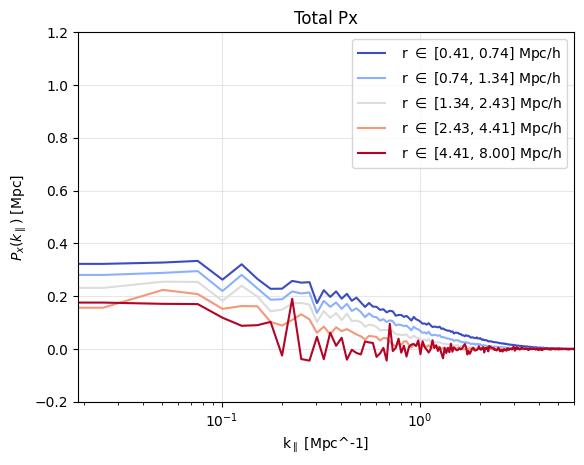

In [15]:
colors = plt.cm.coolwarm(np.linspace(0,1,len(r_bins)-1))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(px_tot)):
    plt.plot(k_los, px_tot[i], label=f' r $\\in$ [%.2f, %.2f] Mpc/h' %(r_bins[i], r_bins[i+1]))
plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.ylim(-0.2, 1.2)
plt.xlabel(r'k$_\parallel$ [Mpc^-1]')
plt.ylabel(r'$P_x(k_\parallel)$ [Mpc]')
plt.title('Total Px');

## Lya

In [17]:
fft_A = fft_lya_grid
fft_B = fft_lya_grid
px_lya = px_calc(r_bins, row_in, col_in, Nsk, colden_grid, fft_A, fft_B)*Lbox*hubble/(Np**2)

rbin | # valid pairs | # masked pairs 
0  |  8081  |  1720
1  |  7685  |  3836
2  |  4753  |  8884
3  |  981  |  17704
4  |  4  |  27501


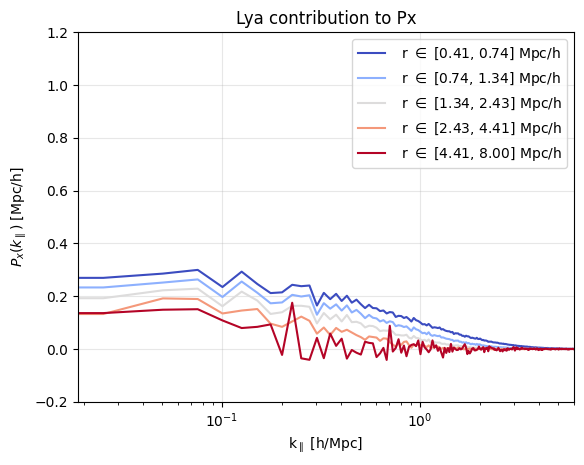

In [18]:
colors = plt.cm.coolwarm(np.linspace(0,1,len(r_bins)-1))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(px_lya)):
    plt.plot(k_los, px_lya[i], label=f' r $\\in$ [%.2f, %.2f] Mpc/h' %(r_bins[i], r_bins[i+1]))
plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.ylim(-0.2, 1.2)
plt.xlabel(r'k$_\parallel$ [h/Mpc]')
plt.ylabel(r'$P_x(k_\parallel)$ [Mpc/h]')
plt.title('Lya contribution to Px');

## HCD

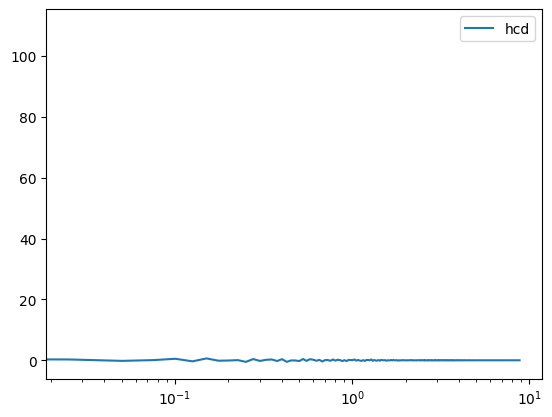

In [25]:
plt.plot(k_los, fft_lya[23], label='lya')
plt.plot(k_los, fft_hcd[23], label='hcd')
plt.xscale('log')
plt.legend()

In [19]:
fft_A = fft_hcd_grid
fft_B = fft_hcd_grid
px_hcd = px_calc(r_bins, row_in, col_in, Nsk, colden_grid, fft_A, fft_B)*Lbox*hubble/(Np**2)

rbin | # valid pairs | # masked pairs 
0  |  8081  |  1720
1  |  7685  |  3836
2  |  4753  |  8884
3  |  981  |  17704
4  |  4  |  27501


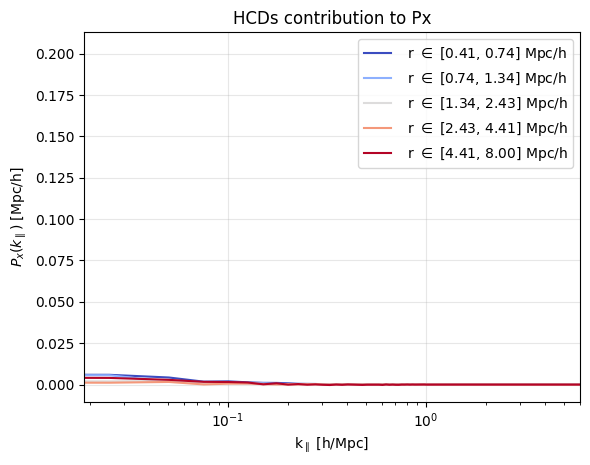

In [20]:
colors = plt.cm.coolwarm(np.linspace(0,1,len(r_bins)-1))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(px_hcd)):
    plt.plot(k_los, px_hcd[i], label=f' r $\\in$ [%.2f, %.2f] Mpc/h' %(r_bins[i], r_bins[i+1]))
plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.xlabel(r'k$_\parallel$ [h/Mpc]')
plt.ylabel(r'$P_x(k_\parallel)$ [Mpc/h]')
plt.title('HCDs contribution to Px');

## Lya x HCDs

In [51]:
fft_A = fft_lya_grid
fft_B = fft_hcd_grid
px_lyahcd = px_calc(r_bins, row_in, col_in, Nsk, colden_grid, fft_A, fft_B)*Lbox/(hubble*(Np**2))

rbin | # valid pairs | # masked pairs 
0  |  8354  |  1447
1  |  8018  |  3230
2  |  6104  |  6927
3  |  4036  |  12692
4  |  2214  |  20279
5  |  93  |  20811
6  |  78  |  21358
7  |  18  |  21565
8  |  7  |  21783


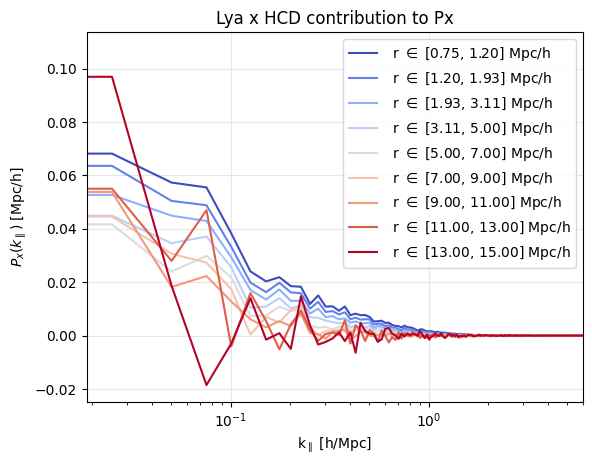

In [52]:
colors = plt.cm.coolwarm(np.linspace(0,1,len(r_bins)-1))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(px_lyahcd)):
    plt.plot(k_los, px_lyahcd[i], label=f' r $\\in$ [%.2f, %.2f] Mpc/h' %(r_bins[i], r_bins[i+1]))
plt.xscale('log')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.xlabel(r'k$_\parallel$ [h/Mpc]')
plt.ylabel(r'$P_x(k_\parallel)$ [Mpc/h]')
plt.title('Lya x HCD contribution to Px');

## 3Lya

In [53]:
fft_A = fft_lya_grid
fft_B = fft_lyahcd_grid
px_3lya = px_calc(r_bins, row_in, col_in, Nsk, colden_grid, fft_A, fft_B)*Lbox/(hubble*(Np**2))

rbin | # valid pairs | # masked pairs 
0  |  8354  |  1447
1  |  8018  |  3230
2  |  6104  |  6927
3  |  4036  |  12692
4  |  2214  |  20279
5  |  93  |  20811
6  |  78  |  21358
7  |  18  |  21565
8  |  7  |  21783


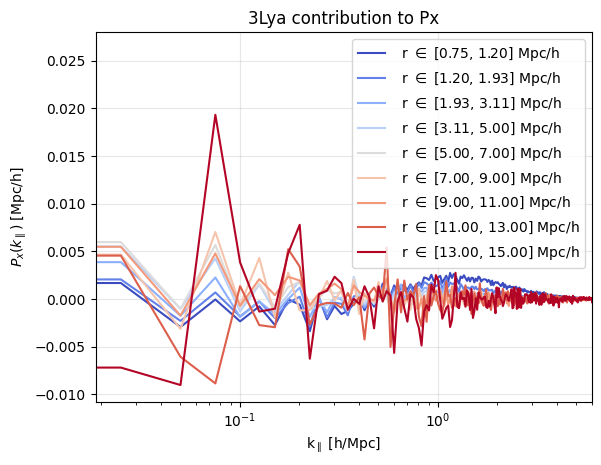

In [54]:
colors = plt.cm.coolwarm(np.linspace(0,1,len(r_bins)-1))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(px_3lya)):
    plt.plot(k_los, px_3lya[i], label=f' r $\\in$ [%.2f, %.2f] Mpc/h' %(r_bins[i], r_bins[i+1]))
plt.xscale('log')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.xlabel(r'k$_\parallel$ [h/Mpc]')
plt.ylabel(r'$P_x(k_\parallel)$ [Mpc/h]')
plt.title('3Lya contribution to Px');

## 3HCD

In [55]:
fft_A = fft_hcd_grid
fft_B = fft_lyahcd_grid
px_3hcd = px_calc(r_bins, row_in, col_in, Nsk, colden_grid, fft_A, fft_B)*Lbox/(hubble*(Np**2))

rbin | # valid pairs | # masked pairs 
0  |  8354  |  1447
1  |  8018  |  3230
2  |  6104  |  6927
3  |  4036  |  12692
4  |  2214  |  20279
5  |  93  |  20811
6  |  78  |  21358
7  |  18  |  21565
8  |  7  |  21783


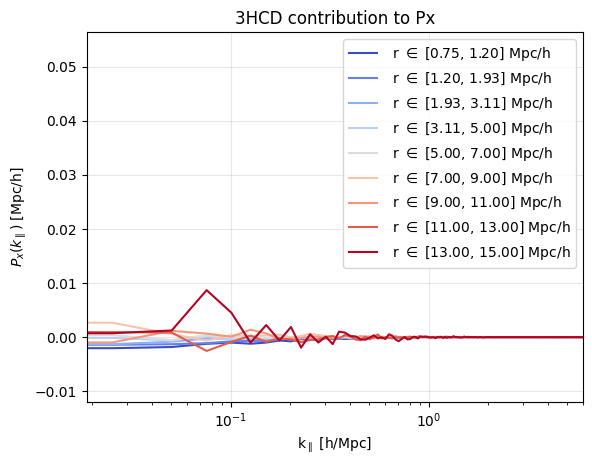

In [56]:
colors = plt.cm.coolwarm(np.linspace(0,1,len(r_bins)-1))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(px_3hcd)):
    plt.plot(k_los, px_3hcd[i], label=f' r $\\in$ [%.2f, %.2f] Mpc/h' %(r_bins[i], r_bins[i+1]))
plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.xlabel(r'k$_\parallel$ [h/Mpc]')
plt.ylabel(r'$P_x(k_\parallel)$ [Mpc/h]')
plt.title('3HCD contribution to Px');

## 4

In [57]:
fft_A = fft_lyahcd_grid
fft_B = fft_lyahcd_grid
px_4 = px_calc(r_bins, row_in, col_in, Nsk, colden_grid, fft_A, fft_B)*Lbox/(hubble*(Np**2))

rbin | # valid pairs | # masked pairs 
0  |  8354  |  1447
1  |  8018  |  3230
2  |  6104  |  6927
3  |  4036  |  12692
4  |  2214  |  20279
5  |  93  |  20811
6  |  78  |  21358
7  |  18  |  21565
8  |  7  |  21783


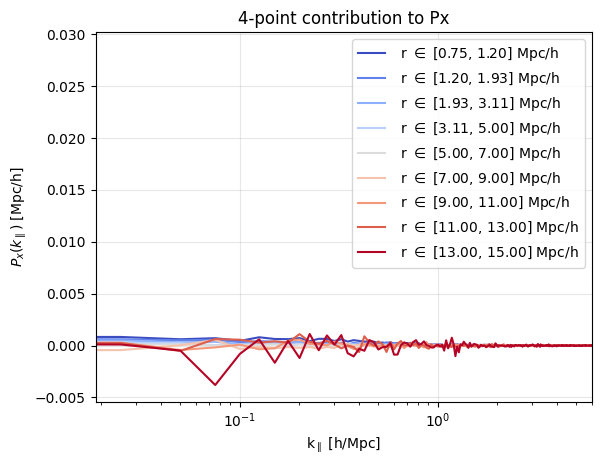

In [58]:
colors = plt.cm.coolwarm(np.linspace(0,1,len(r_bins)-1))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(px_4)):
    plt.plot(k_los, px_4[i], label=f' r $\\in$ [%.2f, %.2f] Mpc/h' %(r_bins[i], r_bins[i+1]))
plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.xlabel(r'k$_\parallel$ [h/Mpc]')
plt.ylabel(r'$P_x(k_\parallel)$ [Mpc/h]')
plt.title('4-point contribution to Px');

# Plots

In [59]:
px_34 = 2*px_3lya + 2*px_3hcd + px_4
px_model = (px_lya + px_hcd + (2*px_lyahcd) + px_34)/((1+C)**2)

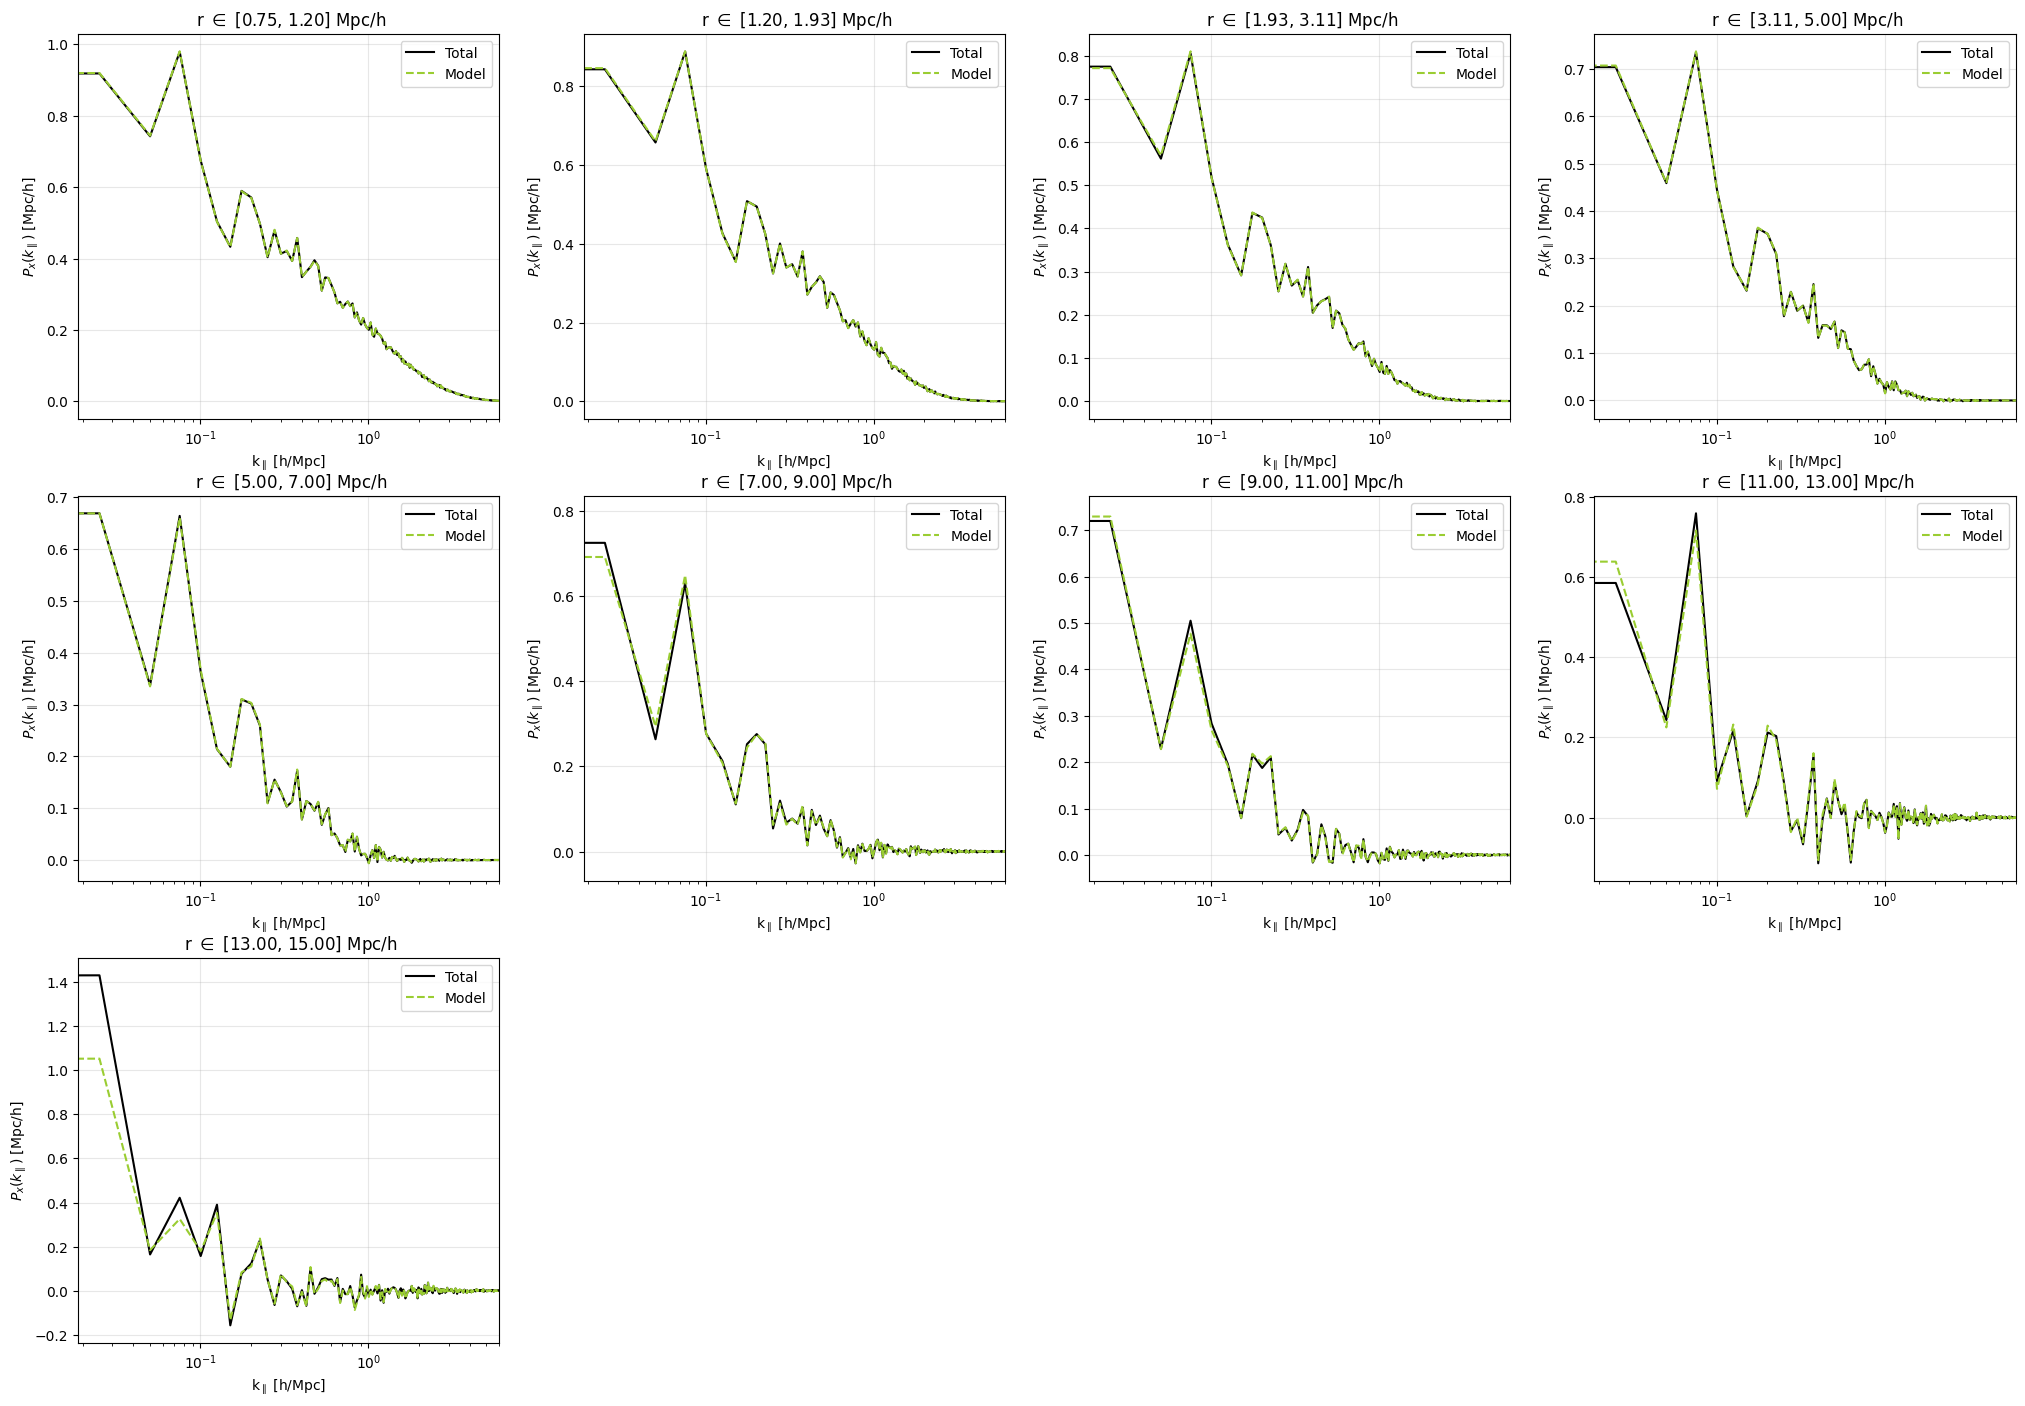

In [60]:
plt.figure(figsize=(25, 17))

for i in np.arange(len(r_bins)-1):
    plt.subplot(3, 4, i+1)
    plt.plot(k_los, px_tot[i], color='k', label='Total')
    plt.plot(k_los, px_model[i], linestyle='--', color='yellowgreen', label='Model')
    plt.xscale('log')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xlim(right=6)
    plt.xlabel(r'k$_\parallel$ [h/Mpc]')
    plt.ylabel(r'$P_x(k_\parallel)$ [Mpc/h]')
    plt.title(f' r $\\in$ [%.2f, %.2f] Mpc/h' %(r_bins[i], r_bins[i+1]))

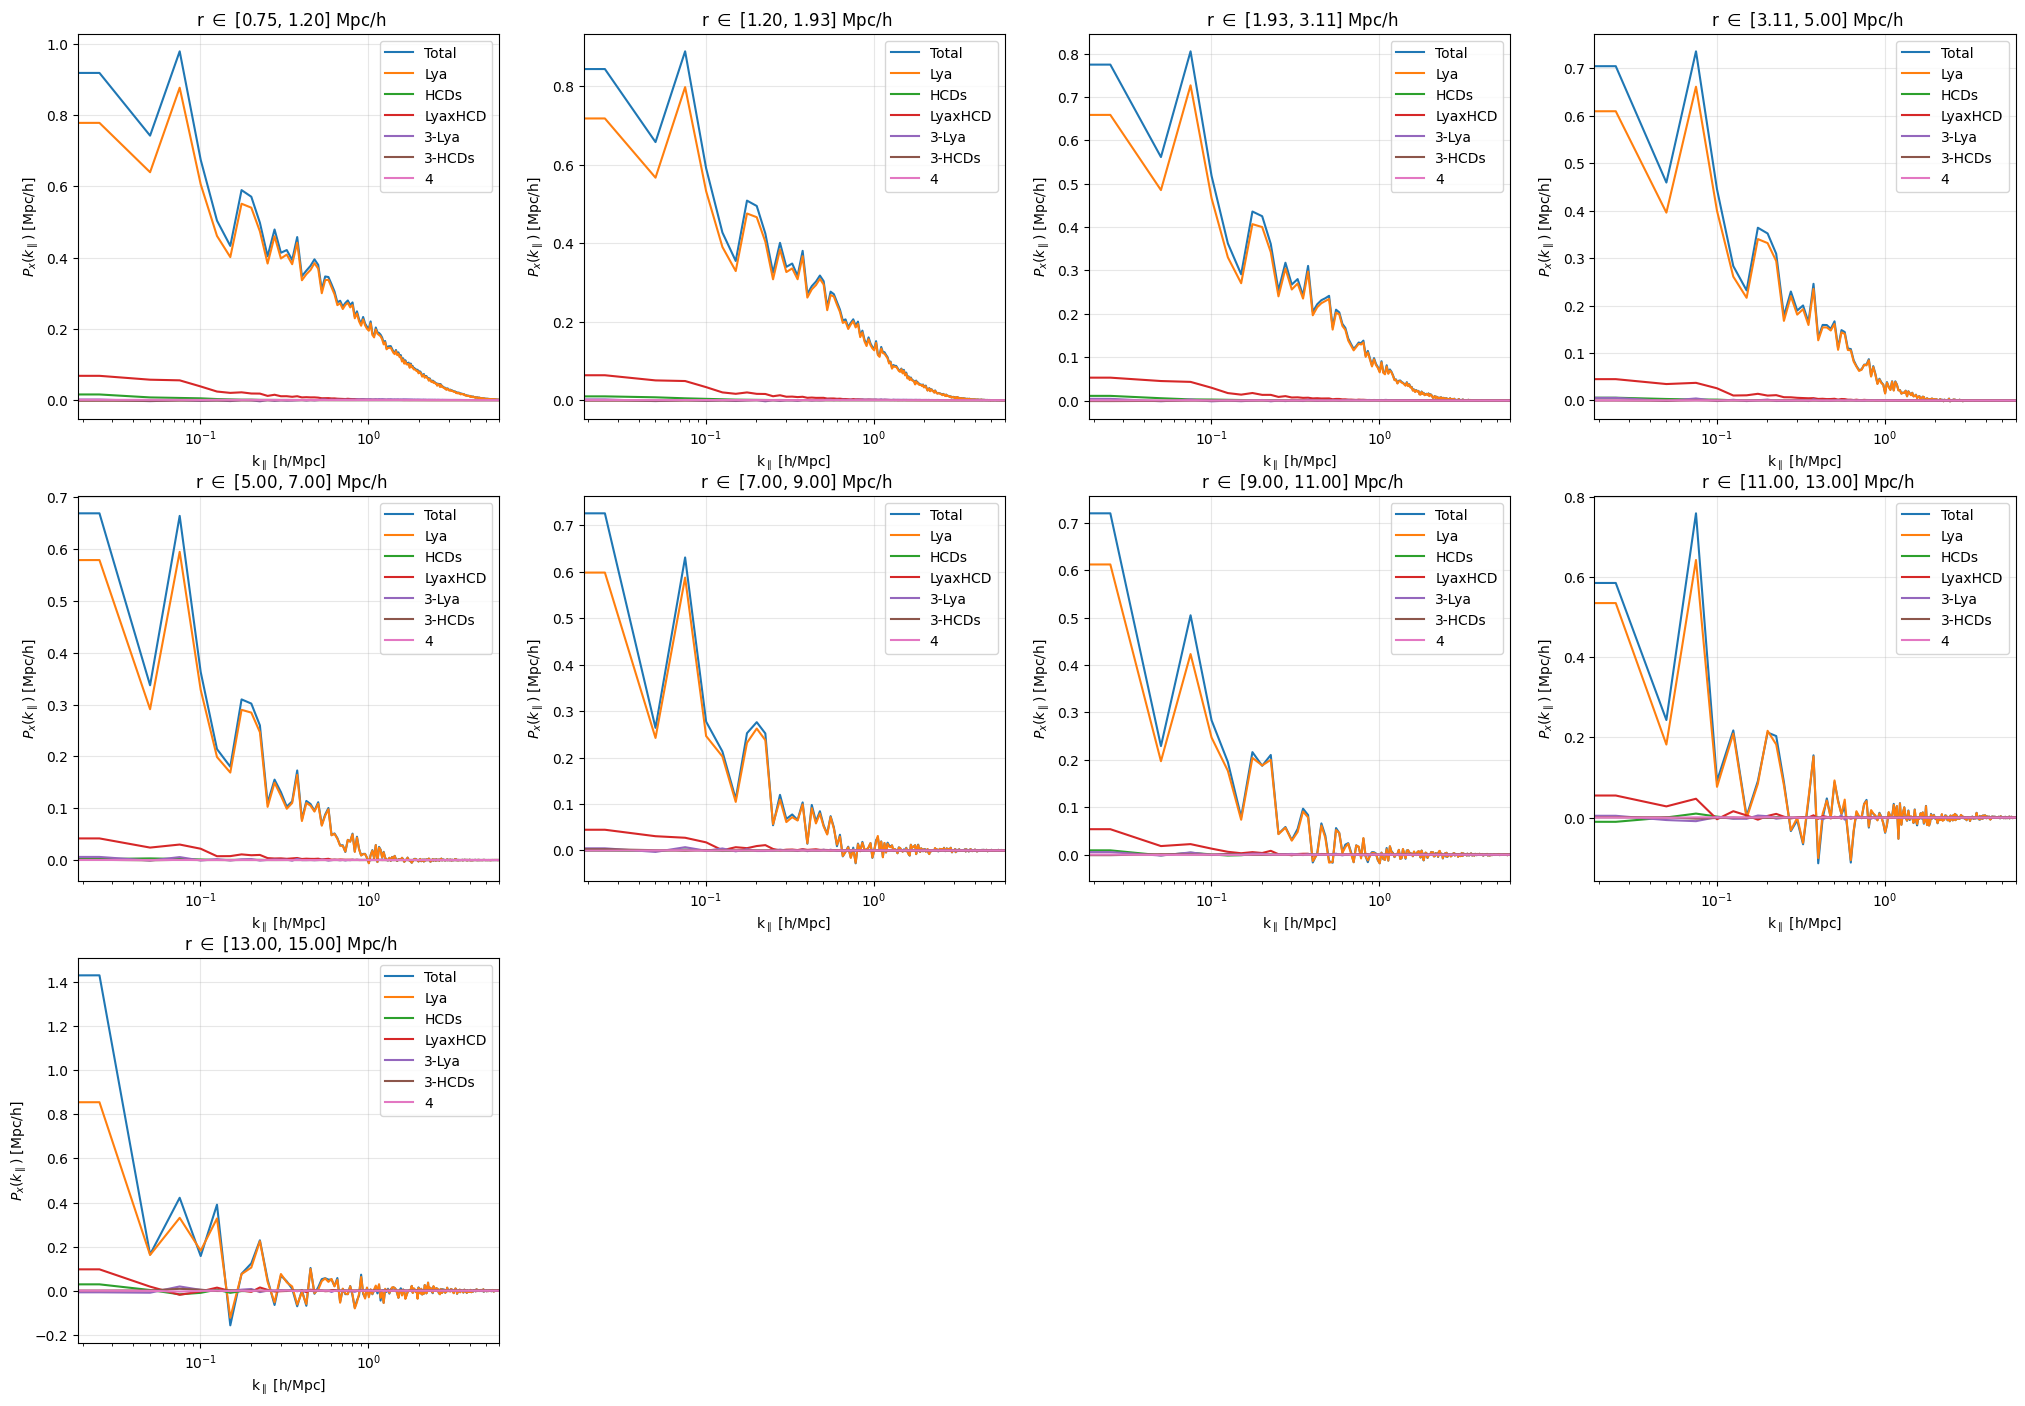

In [61]:
plt.figure(figsize=(25, 17))

for i in np.arange(len(r_bins)-1):
    plt.subplot(3, 4, i+1)
    plt.plot(k_los, px_tot[i], label='Total')
    plt.plot(k_los, px_lya[i], label='Lya')
    plt.plot(k_los, px_hcd[i], label='HCDs')
    plt.plot(k_los, px_lyahcd[i], label='LyaxHCD')
    plt.plot(k_los, px_3lya[i], label='3-Lya')
    plt.plot(k_los, px_3hcd[i], label='3-HCDs')
    plt.plot(k_los, px_4[i], label='4')
    plt.xscale('log')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xlim(right=6)
    plt.xlabel(r'k$_\parallel$ [h/Mpc]')
    plt.ylabel(r'$P_x(k_\parallel)$ [Mpc/h]')
    plt.title(f' r $\\in$ [%.2f, %.2f] Mpc/h' %(r_bins[i], r_bins[i+1]))

In [62]:
px_approx1 = px_lya+px_hcd+(2*px_lyahcd)/((1+C)**2)
px_approx2 = px_lya+px_hcd+(2*px_lyahcd)

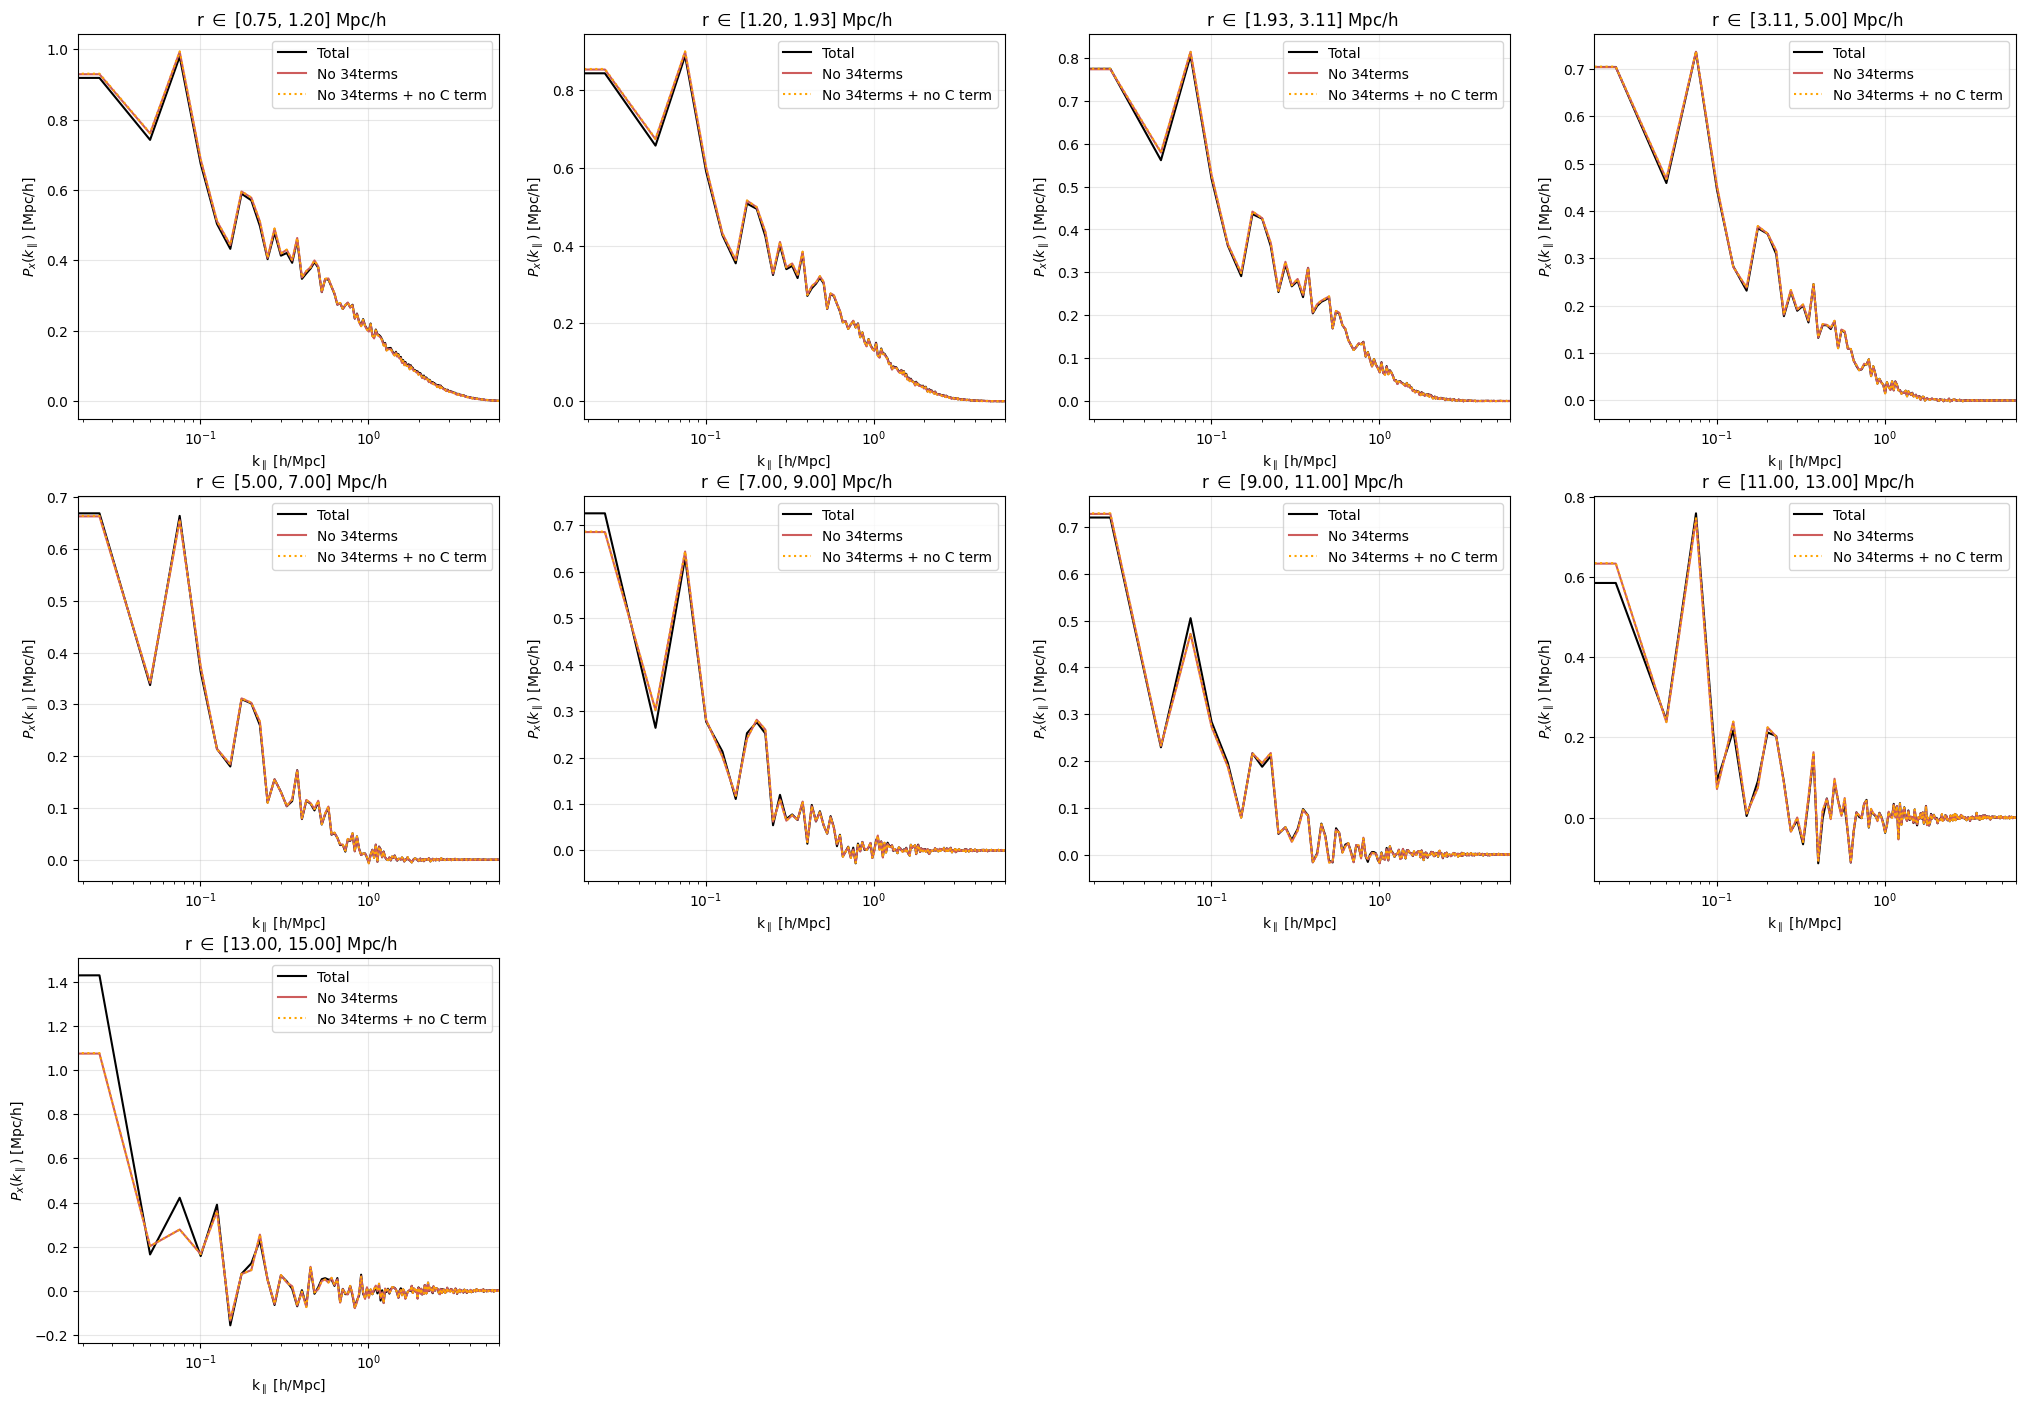

In [63]:
plt.figure(figsize=(25, 17))

for i in np.arange(len(r_bins)-1):
    plt.subplot(3, 4, i+1)
    plt.plot(k_los, px_tot[i], color='k', label='Total')
    plt.plot(k_los, px_approx1[i], color='indianred', label='No 34terms')
    plt.plot(k_los, px_approx2[i], color='orange', linestyle=':', label='No 34terms + no C term')
    plt.xscale('log')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xlim(right=6)
    plt.xlabel(r'k$_\parallel$ [h/Mpc]')
    plt.ylabel(r'$P_x(k_\parallel)$ [Mpc/h]')
    plt.title(f' r $\\in$ [%.2f, %.2f] Mpc/h' %(r_bins[i], r_bins[i+1]))

In [69]:
lost_info = np.abs((px_approx1-px_tot)*100)

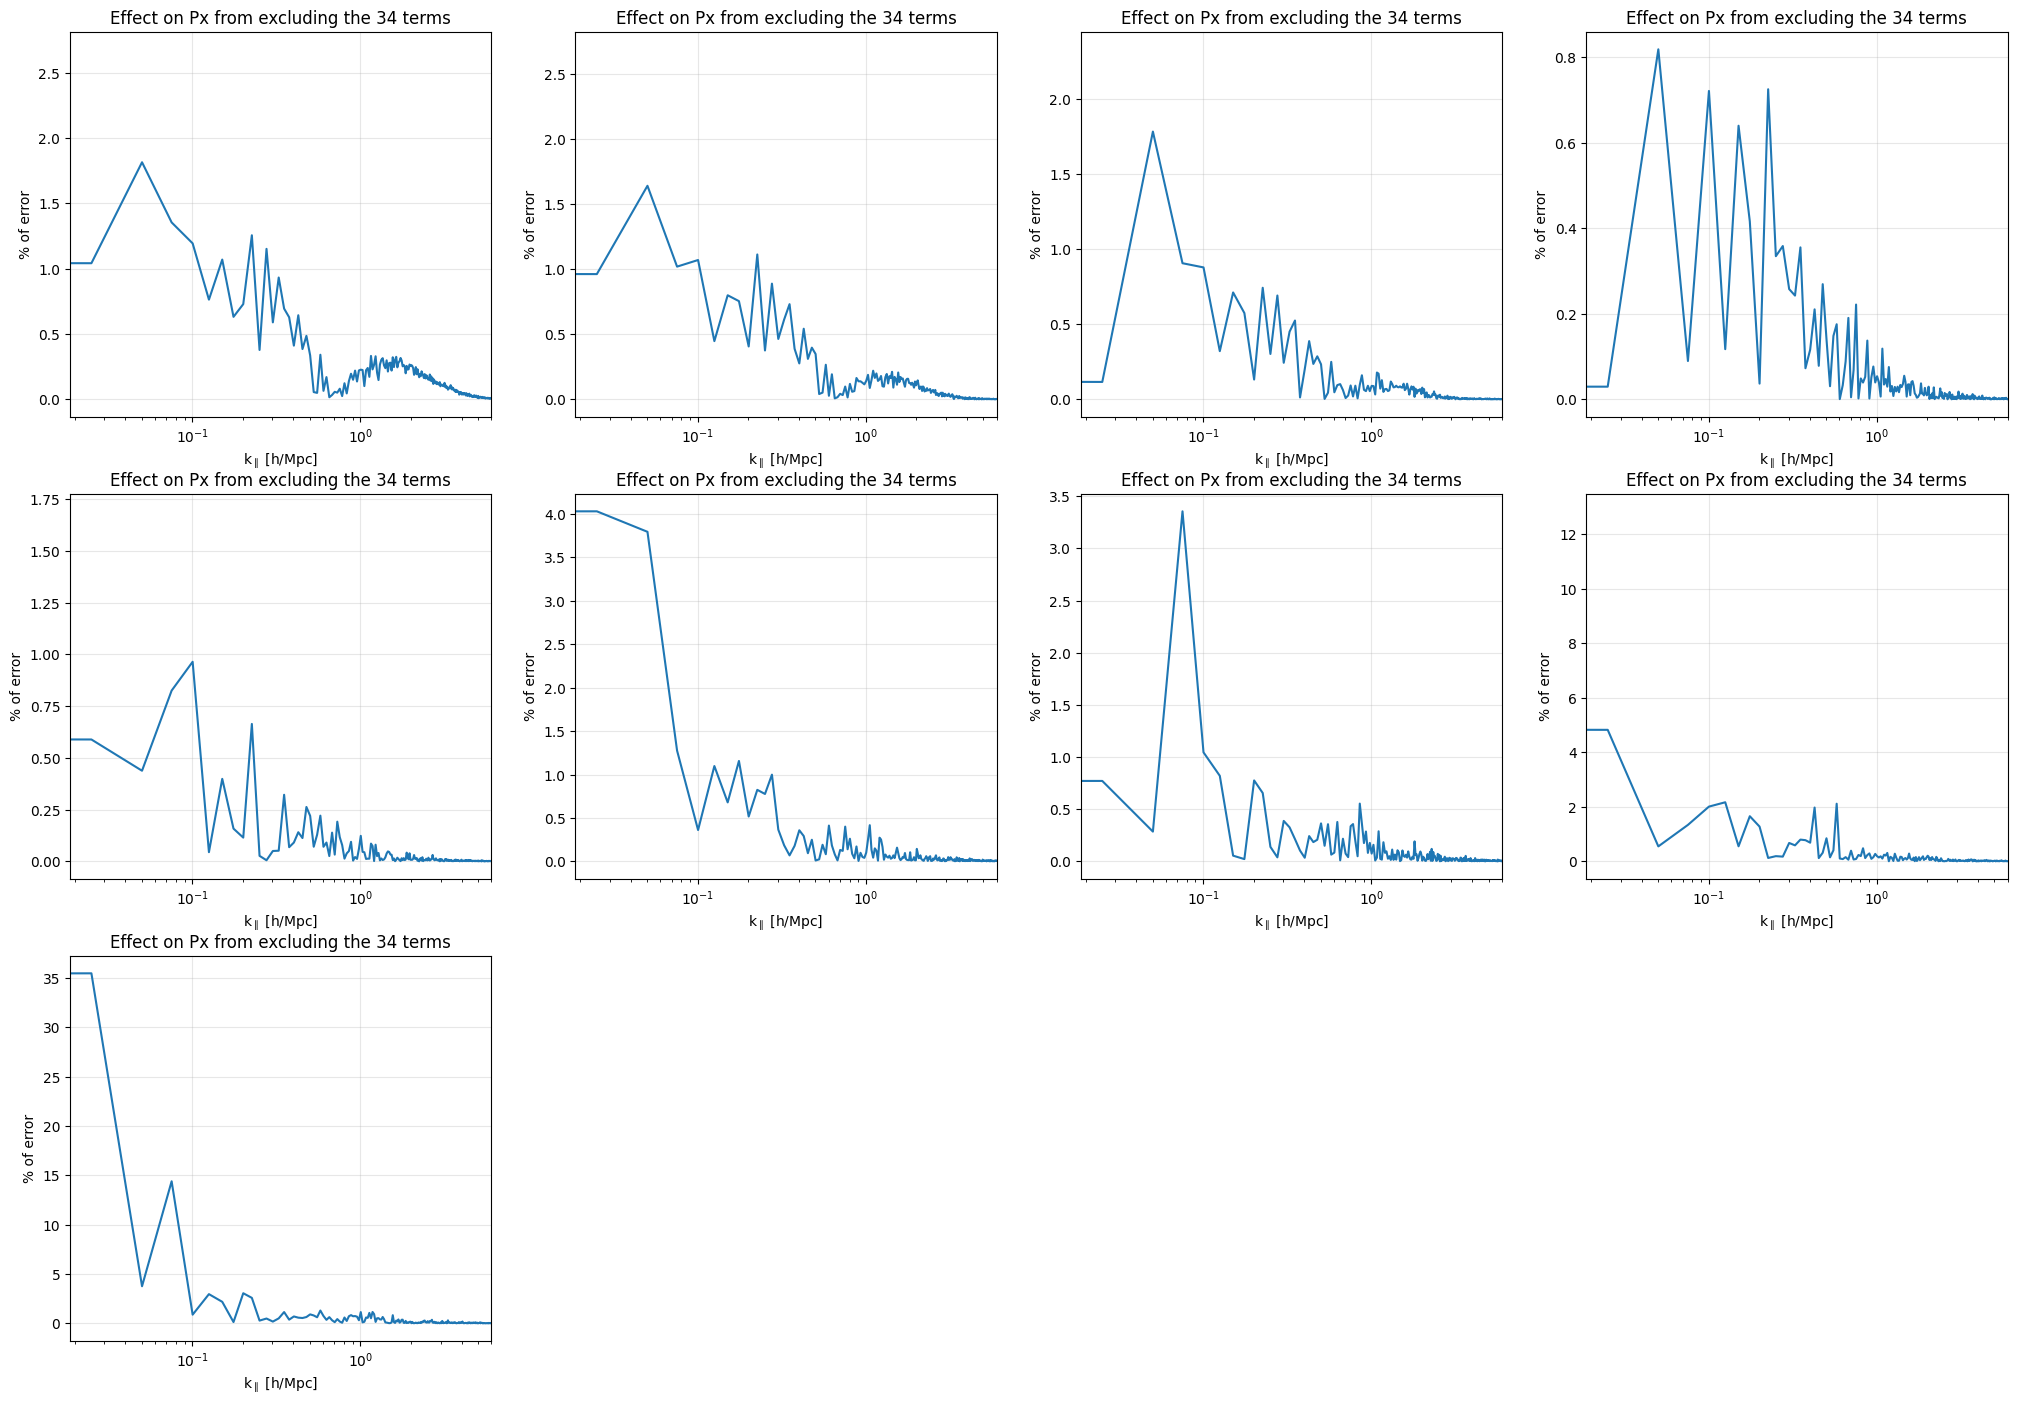

In [70]:
plt.figure(figsize=(25, 17))

for i in np.arange(len(r_bins)-1):
    plt.subplot(3, 4, i+1)
    plt.plot(k_los, lost_info[i, :])
    plt.xscale('log')
    plt.grid(alpha=0.3)
    plt.xlim(right=6)
    plt.xlabel(r'k$_\parallel$ [h/Mpc]')
    plt.ylabel('% of error')
    plt.title('Effect on Px from excluding the 34 terms');

# Reading the script outcome

In [3]:
data = '/pscratch/sd/l/lflores/astrid_hcd_outputs/pxs_0.3_21.3.hdf5'

with h5py.File(data, 'r') as f:
    print('Atributes:')
    for m in f.attrs.keys():
        print(f'{m} = {f.attrs[m]}')
    print('----------------') 
    print('Data:')
    print(f.keys())
    k_los = f['k_los'][:]
    print('k_los shape:', k_los.shape)
    pxs_tot = f['px_tot'][:]
    print('pxs_tot shape:', pxs_tot.shape)
    pxs_lya = f['px_lya'][:]
    print('pxs_lya shape:', pxs_lya.shape)
    pxs_hcd = f['px_hcd'][:]
    print('px_hcd shape:', pxs_hcd.shape)
    pxs_lyahcd = f['px_lyahcd'][:]
    print('pxs_lyahcd shape:', pxs_lyahcd.shape)
    pxs_3lya = f['px_3lya'][:]
    print('p1d_3lya shape:', pxs_3lya.shape)
    pxs_3hcd = f['px_3hcd'][:]
    print('pxs_3hcd shape:', pxs_3hcd.shape)
    pxs_4 = f['px_4'][:]
    print('pxs_4 shape:', pxs_4.shape)
    Cs = f['C'][()]
    print('Cs shape = ', Cs.shape)
    r_bins = f['r_bins'][:]
    print('Radial bins:', r_bins, 'Mpc/h')

Atributes:
----- WARNING ----- = Units in terms of h
Smoothing factor = 0.3
logNHI_max = 40.0
logNHI_min = 0
minibox_size_Mpch = 250
pixel_width_Mpch = 0.1
pixels_per_skewer = 2500
skewer_separation_Mpch = 0.5
skewers_per_side = 100
----------------
Data:
<KeysViewHDF5 ['C', 'k_los', 'px_3hcd', 'px_3lya', 'px_4', 'px_hcd', 'px_lya', 'px_lyahcd', 'px_tot', 'r_bins']>
k_los shape: (351,)
pxs_tot shape: (25, 5, 351)
pxs_lya shape: (25, 5, 351)
px_hcd shape: (25, 5, 351)
pxs_lyahcd shape: (25, 5, 351)
p1d_3lya shape: (25, 5, 351)
pxs_3hcd shape: (25, 5, 351)
pxs_4 shape: (25, 5, 351)
Cs shape =  (25,)
Radial bins: [0.40505051 0.73557226 1.33580019 2.42581492 4.40528312 8.        ] Mpc/h


In [4]:
k_los /= hubble  # In Mpc^-1
r_bins *= hubble  # In Mpc
pxs_tot *= hubble  # In Mpc
pxs_lya *= hubble 
pxs_hcd *= hubble 
pxs_lyahcd *= hubble 
pxs_3lya *= hubble 
pxs_3hcd *= hubble 
pxs_4 *= hubble 

Let's make the mean of all the boxes

In [5]:
Nmbox = pxs_tot[:, 0].shape[0]
Px_tot, Px_std_tot = np.mean(pxs_tot, axis=0), np.std(pxs_tot, axis=0)/np.sqrt(Nmbox-1)
Px_lya, Px_std_lya = np.mean(pxs_lya, axis=0), np.std(pxs_lya, axis=0)/np.sqrt(Nmbox-1)
Px_hcd, Px_std_hcd = np.mean(pxs_hcd, axis=0), np.std(pxs_hcd, axis=0)/np.sqrt(Nmbox-1)
Px_lyahcd, Px_std_lyahcd = np.mean(pxs_lyahcd, axis=0), np.std(pxs_lyahcd, axis=0)/np.sqrt(Nmbox-1)
Px_3lya, Px_std_3lya = np.mean(pxs_3lya, axis=0), np.std(pxs_3lya, axis=0)/np.sqrt(Nmbox-1)
Px_3hcd, Px_std_3hcd = np.mean(pxs_3hcd, axis=0), np.std(pxs_3hcd, axis=0)/np.sqrt(Nmbox-1)
Px_4, Px_std_4 = np.mean(pxs_4, axis=0), np.std(pxs_4, axis=0)/np.sqrt(Nmbox-1)
C, C_std = np.mean(Cs), np.std(Cs)/np.sqrt(Nmbox-1)
print('C =', C, '+-', C_std)

C = 0.0065004926842351105 +- 0.00012198128332281223


In [6]:
Px_34 = 2*Px_3lya + 2*Px_3hcd + Px_4
Px_model = (Px_lya + Px_hcd + (2*Px_lyahcd) + Px_34)/((1+C)**2)

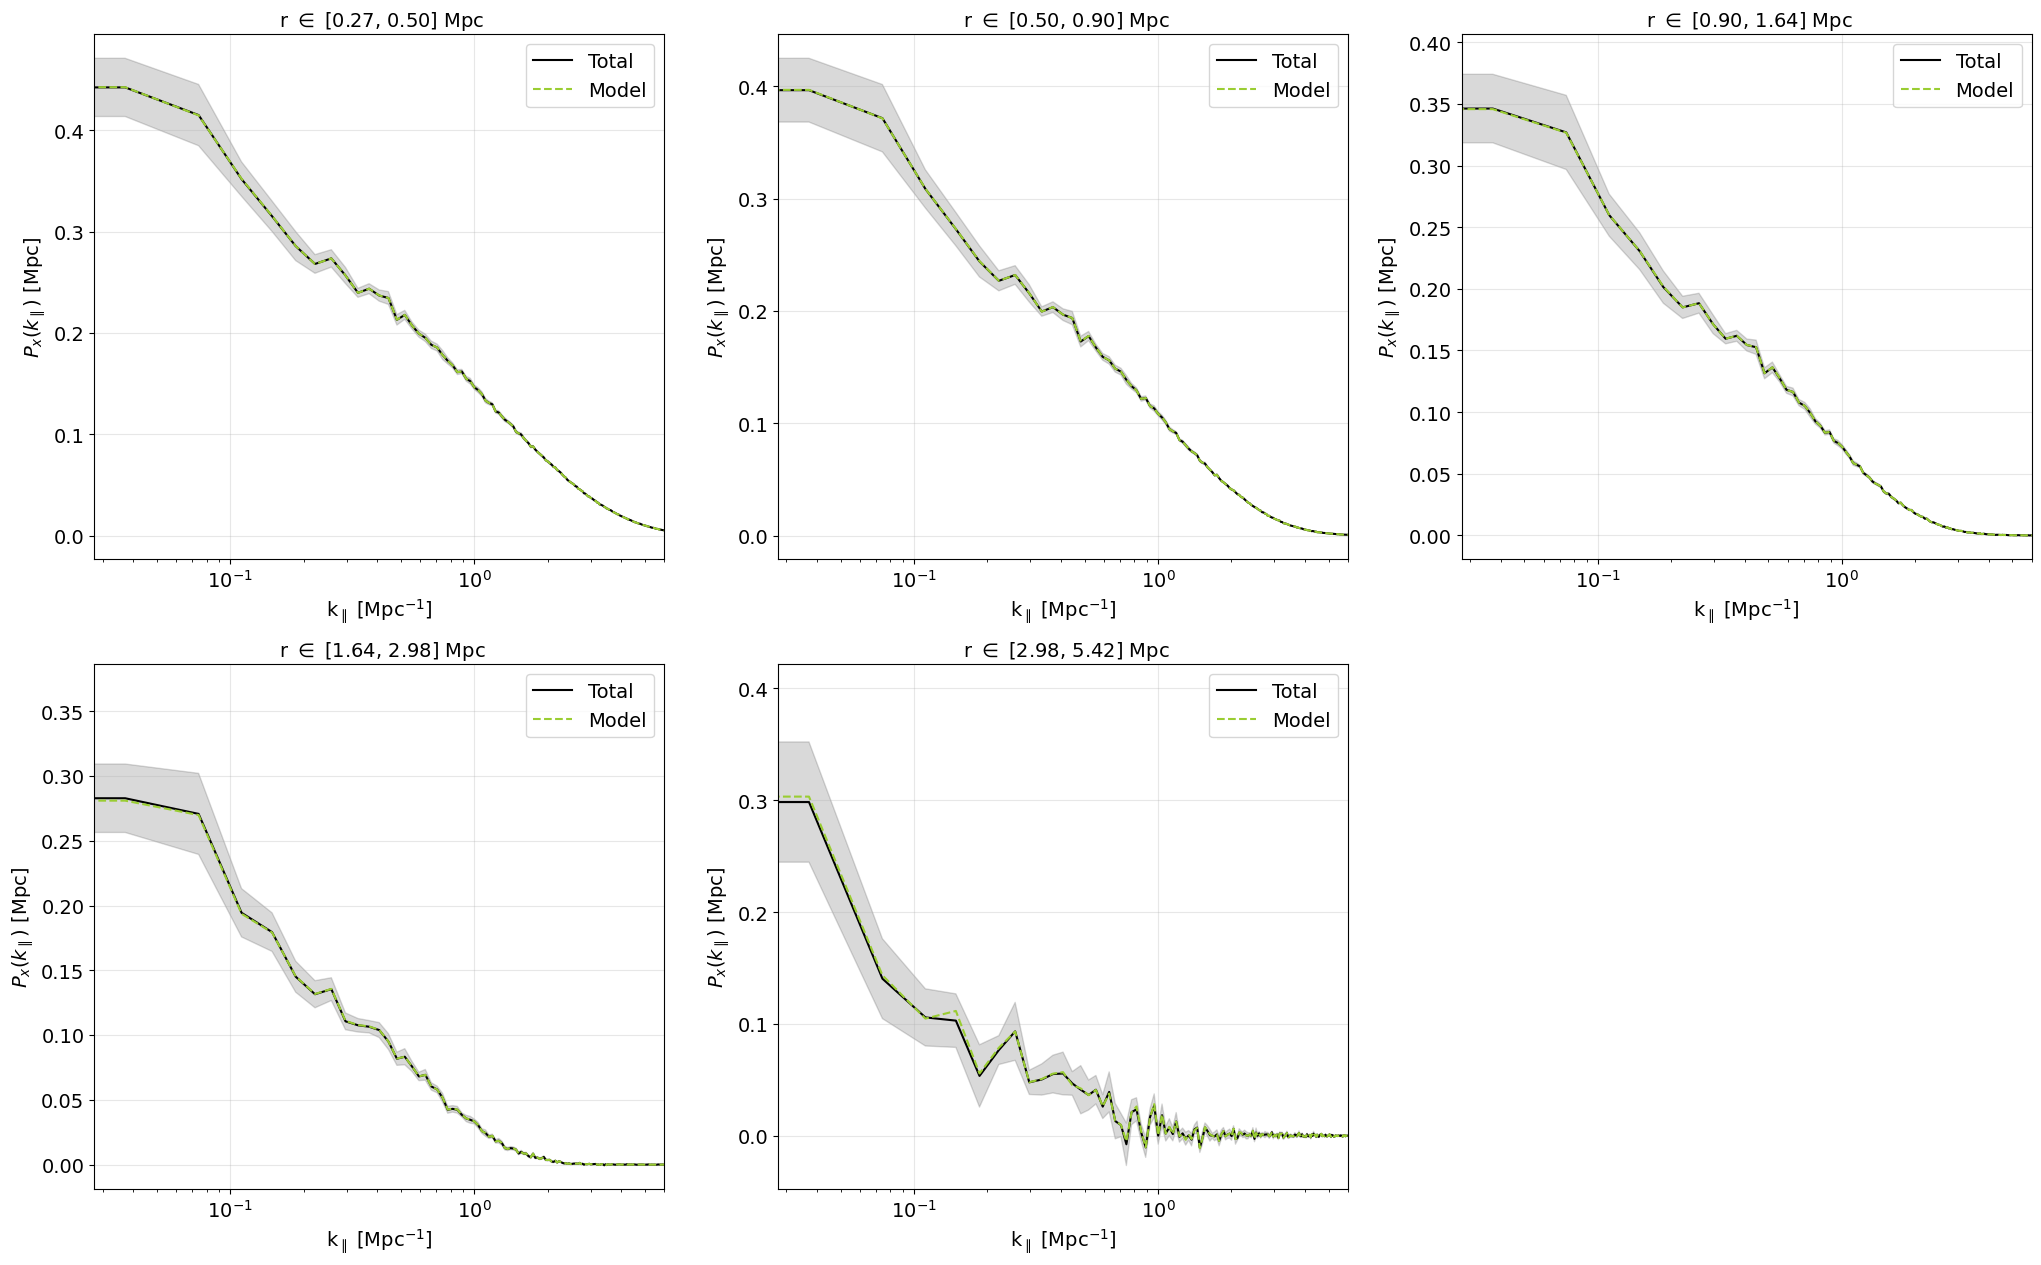

In [12]:
plt.figure(figsize=(25, 15))

for i in np.arange(len(r_bins)-1):
    plt.subplot(2, 3, i+1)
    plt.plot(k_los, Px_tot[i], color='k', label='Total')
    plt.fill_between(k_los, (Px_tot[i]-Px_std_tot[i]), (Px_tot[i]+Px_std_tot[i]), color='k', alpha=0.15)
    plt.plot(k_los, Px_model[i], linestyle='--', color='yellowgreen', label='Model')

    plt.xscale('log')
    plt.legend(fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(alpha=0.3)
    plt.xlim(right=6)
    plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]', fontsize=14)
    plt.ylabel(r'$P_{x}(k_\parallel)$ [Mpc]', fontsize=14)
    plt.title(f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]), fontsize=14);

    plt.savefig('plot.png', dpi=200, bbox_inches='tight')

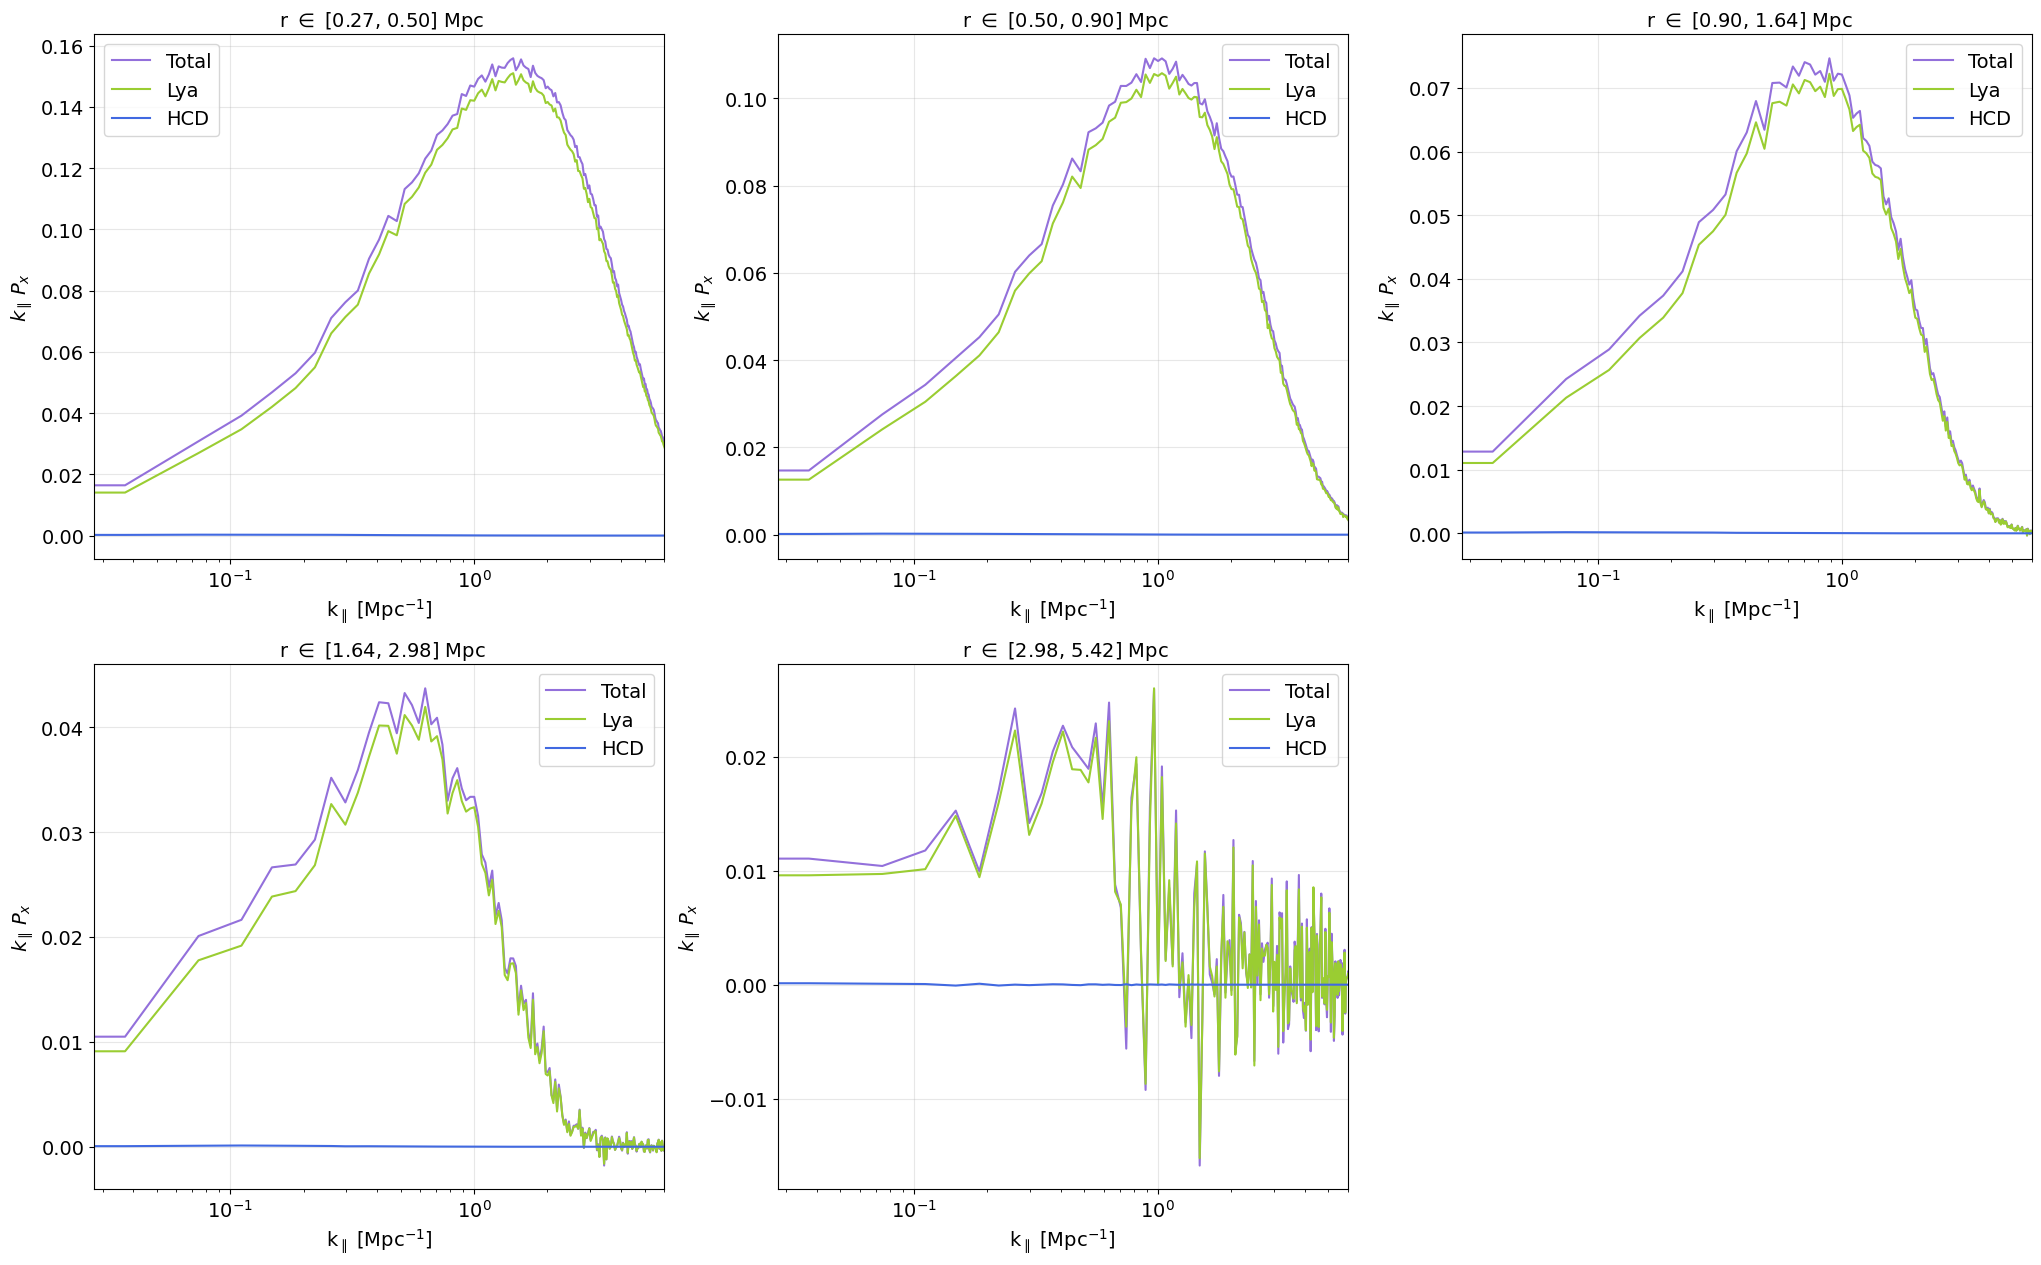

In [13]:
plt.figure(figsize=(25, 15))

for i in np.arange(len(r_bins)-1):
    plt.subplot(2, 3, i+1)
    plt.plot(k_los, Px_tot[i]*k_los, color='mediumpurple', label='Total')
    plt.plot(k_los, Px_lya[i]*k_los, color='yellowgreen', label='Lya')
    plt.plot(k_los, Px_hcd[i]*k_los, color='royalblue', label='HCD')
    plt.xscale('log')
    plt.legend(fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(alpha=0.3)
    plt.xlim(right=6)
    plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]', fontsize=14)
    plt.ylabel(r'$k_\parallel \, P_{x}$', fontsize=14)
    plt.title(f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]), fontsize=14);

    plt.savefig('plot.png', dpi=200, bbox_inches='tight')

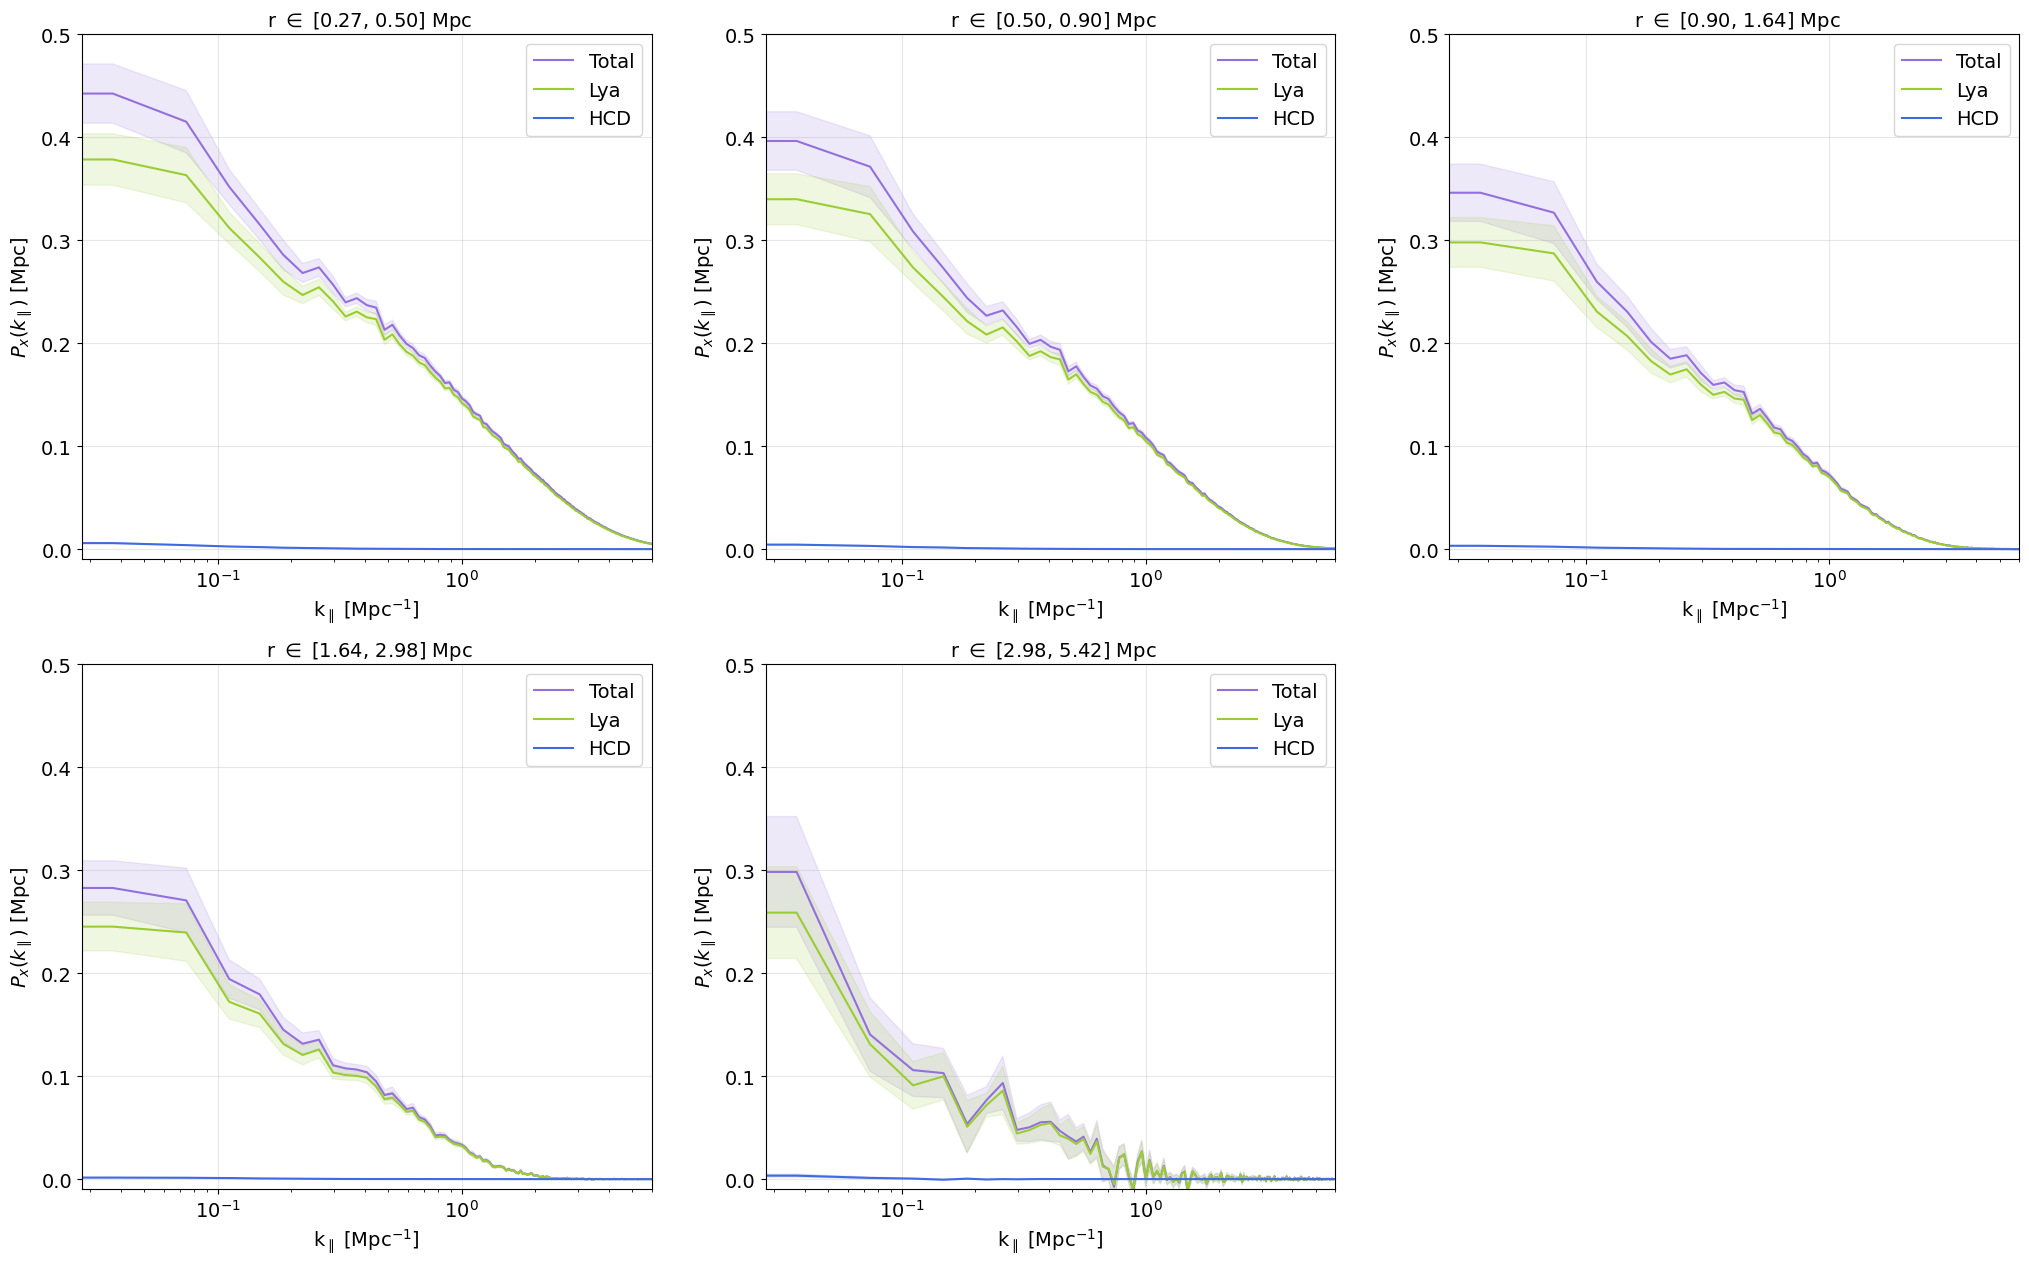

In [14]:
plt.figure(figsize=(25, 15))

for i in np.arange(len(r_bins)-1):
    plt.subplot(2, 3, i+1)
    plt.plot(k_los, Px_tot[i], color='mediumpurple', label='Total')
    plt.fill_between(k_los, (Px_tot[i]-Px_std_tot[i]), (Px_tot[i]+Px_std_tot[i]), color='mediumpurple', alpha=0.15)
    plt.plot(k_los, Px_lya[i], color='yellowgreen', label='Lya')
    plt.fill_between(k_los, (Px_lya[i]-Px_std_lya[i]), (Px_lya[i]+Px_std_lya[i]), color='yellowgreen', alpha=0.15)
    plt.plot(k_los, Px_hcd[i], color='royalblue', label='HCD')
    plt.fill_between(k_los, (Px_hcd[i]-Px_std_hcd[i]), (Px_hcd[i]+Px_std_hcd[i]), color='royalblue', alpha=0.15)
    plt.xscale('log')
    plt.legend(fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(alpha=0.3)
    plt.xlim(right=6)
    plt.ylim(-0.01, 0.5)
    plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]', fontsize=14)
    plt.ylabel(r'$P_{x}(k_\parallel)$ [Mpc]', fontsize=14)
    plt.title(f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]), fontsize=14);

    plt.savefig('plot.png', dpi=200, bbox_inches='tight')

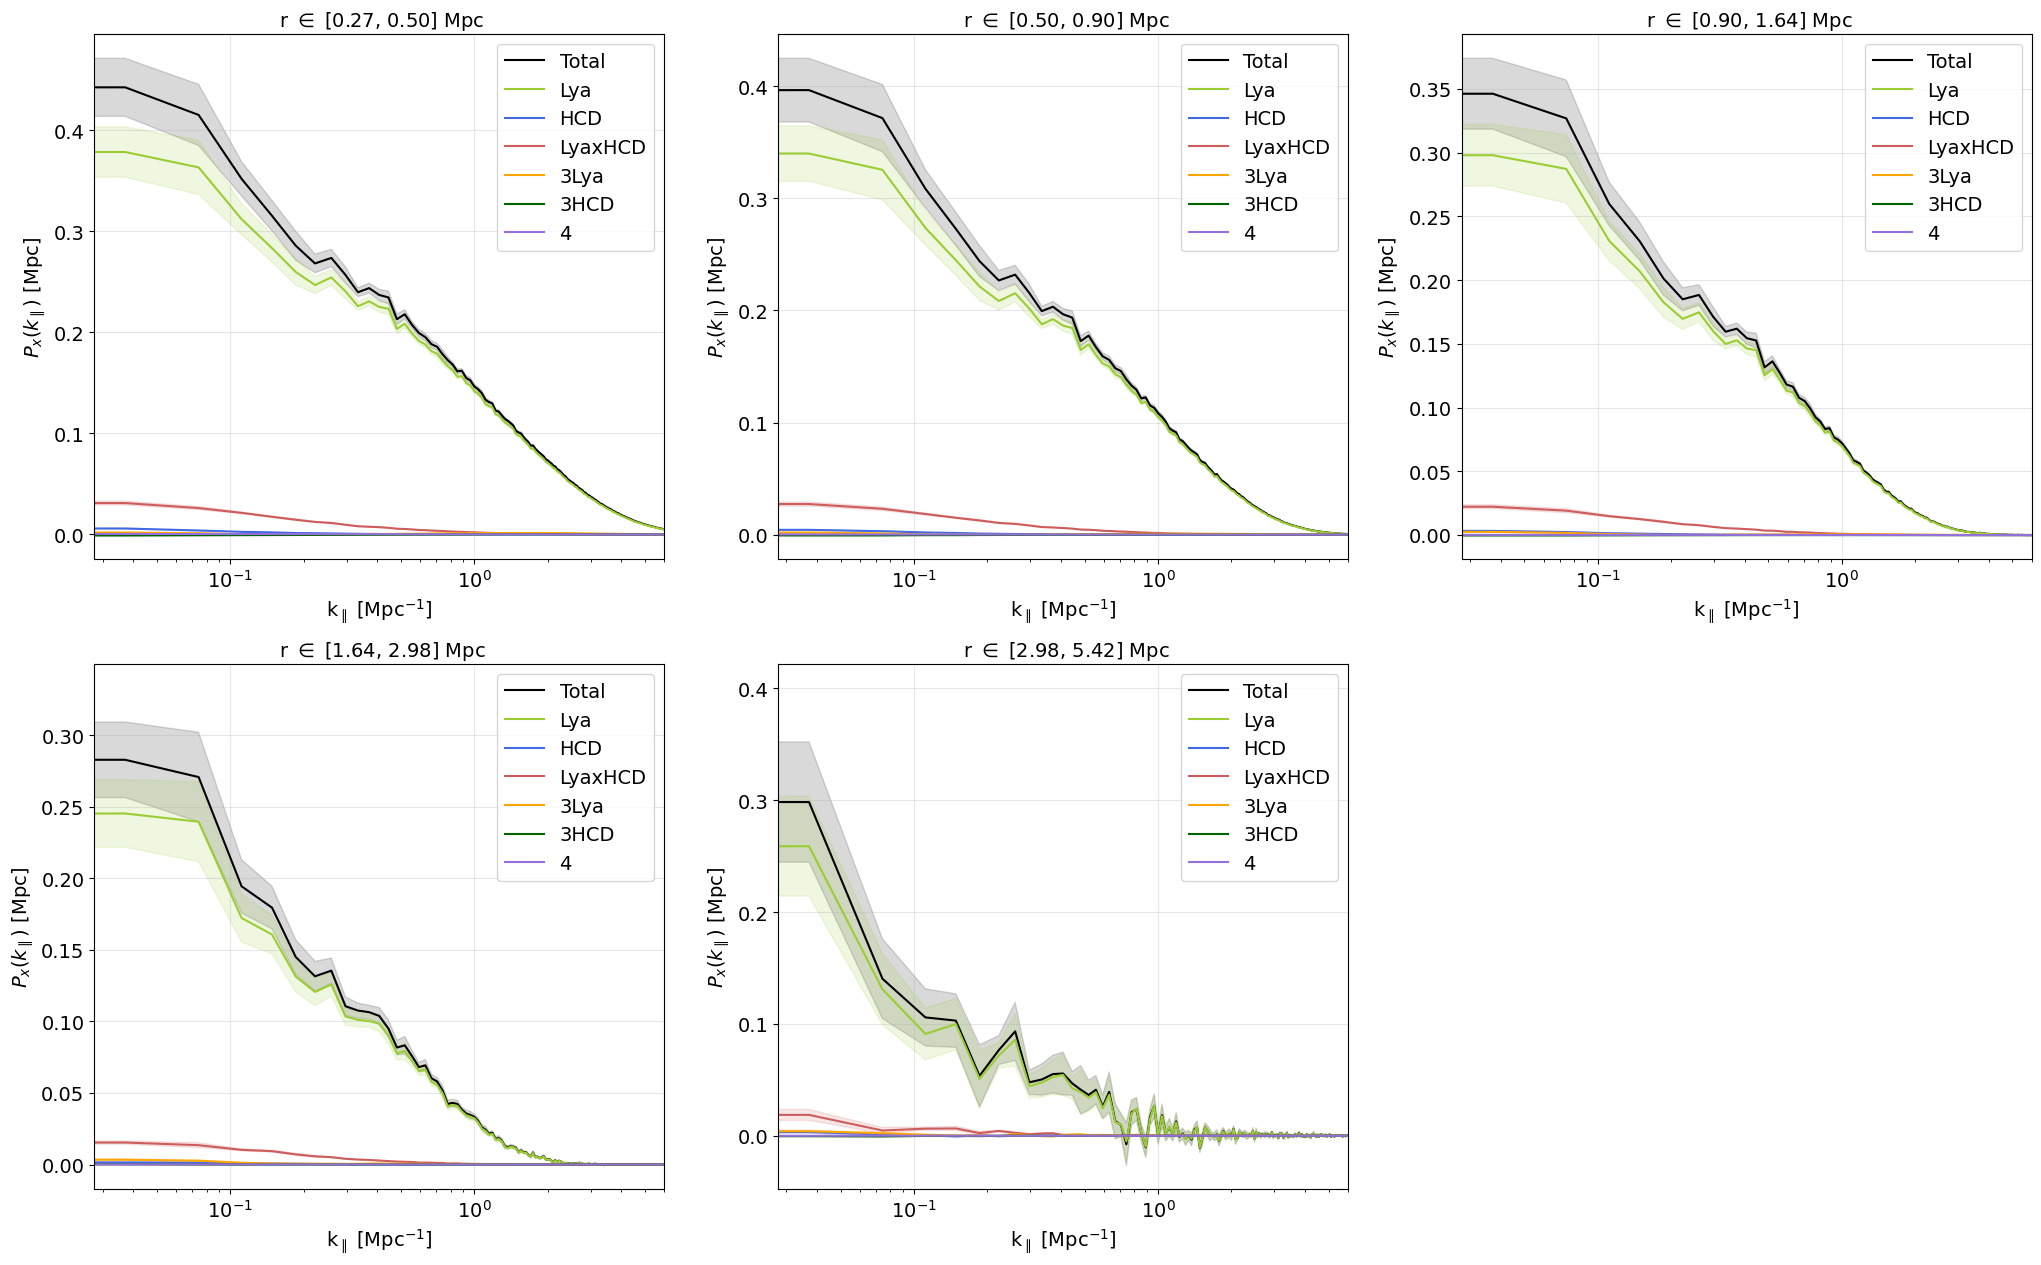

In [16]:
plt.figure(figsize=(25, 15))

for i in np.arange(len(r_bins)-1):
    plt.subplot(2, 3, i+1)
    plt.plot(k_los, Px_tot[i], color='k', label='Total')
    plt.fill_between(k_los, (Px_tot[i]-Px_std_tot[i]), (Px_tot[i]+Px_std_tot[i]), color='k', alpha=0.15)
    plt.plot(k_los, Px_lya[i], color='yellowgreen', label='Lya')
    plt.fill_between(k_los, (Px_lya[i]-Px_std_lya[i]), (Px_lya[i]+Px_std_lya[i]), color='yellowgreen', alpha=0.15)
    plt.plot(k_los, Px_hcd[i], color='royalblue', label='HCD')
    plt.fill_between(k_los, (Px_hcd[i]-Px_std_hcd[i]), (Px_hcd[i]+Px_std_hcd[i]), color='royalblue', alpha=0.15)
    plt.plot(k_los, Px_lyahcd[i], color='indianred', label='LyaxHCD')
    plt.fill_between(k_los, (Px_lyahcd[i]-Px_std_lyahcd[i]), (Px_lyahcd[i]+Px_std_lyahcd[i]), color='indianred', alpha=0.15)
    plt.plot(k_los, Px_3lya[i], color='orange', label='3Lya')
    plt.fill_between(k_los, (Px_3lya[i]-Px_std_3lya[i]), (Px_3lya[i]+Px_std_3lya[i]), color='orange', alpha=0.15)
    plt.plot(k_los, Px_3hcd[i], color='darkgreen', label='3HCD')
    plt.fill_between(k_los, (Px_3hcd[i]-Px_std_3hcd[i]), (Px_3hcd[i]+Px_std_3hcd[i]), color='darkgreen', alpha=0.15)
    plt.plot(k_los, Px_4[i], color='mediumpurple', label='4')
    plt.fill_between(k_los, (Px_4[i]-Px_std_4[i]), (Px_4[i]+Px_std_4[i]), color='mediumpurple', alpha=0.15)

    plt.xscale('log')
    plt.legend(fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(alpha=0.3)
    plt.xlim(right=6)
    plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]', fontsize=14)
    plt.ylabel(r'$P_{x}(k_\parallel)$ [Mpc]', fontsize=14)
    plt.title(f' r $\\in$ [%.2f, %.2f] Mpc' %(r_bins[i], r_bins[i+1]), fontsize=14);

    plt.savefig('plot.png', dpi=200, bbox_inches='tight')

In [17]:
Px_aprox, Px_maxstd_aprox = Px_lya+Px_hcd+(2*Px_lyahcd)/((1+C)**2), Px_std_lya+Px_std_hcd+(2*Px_std_lyahcd)/((1+C)**2)
Px_aprox_vega, Px_maxstd_aprox_vega = Px_lya+Px_hcd+(2*Px_lyahcd), Px_std_lya+Px_std_hcd+(2*Px_std_lyahcd)

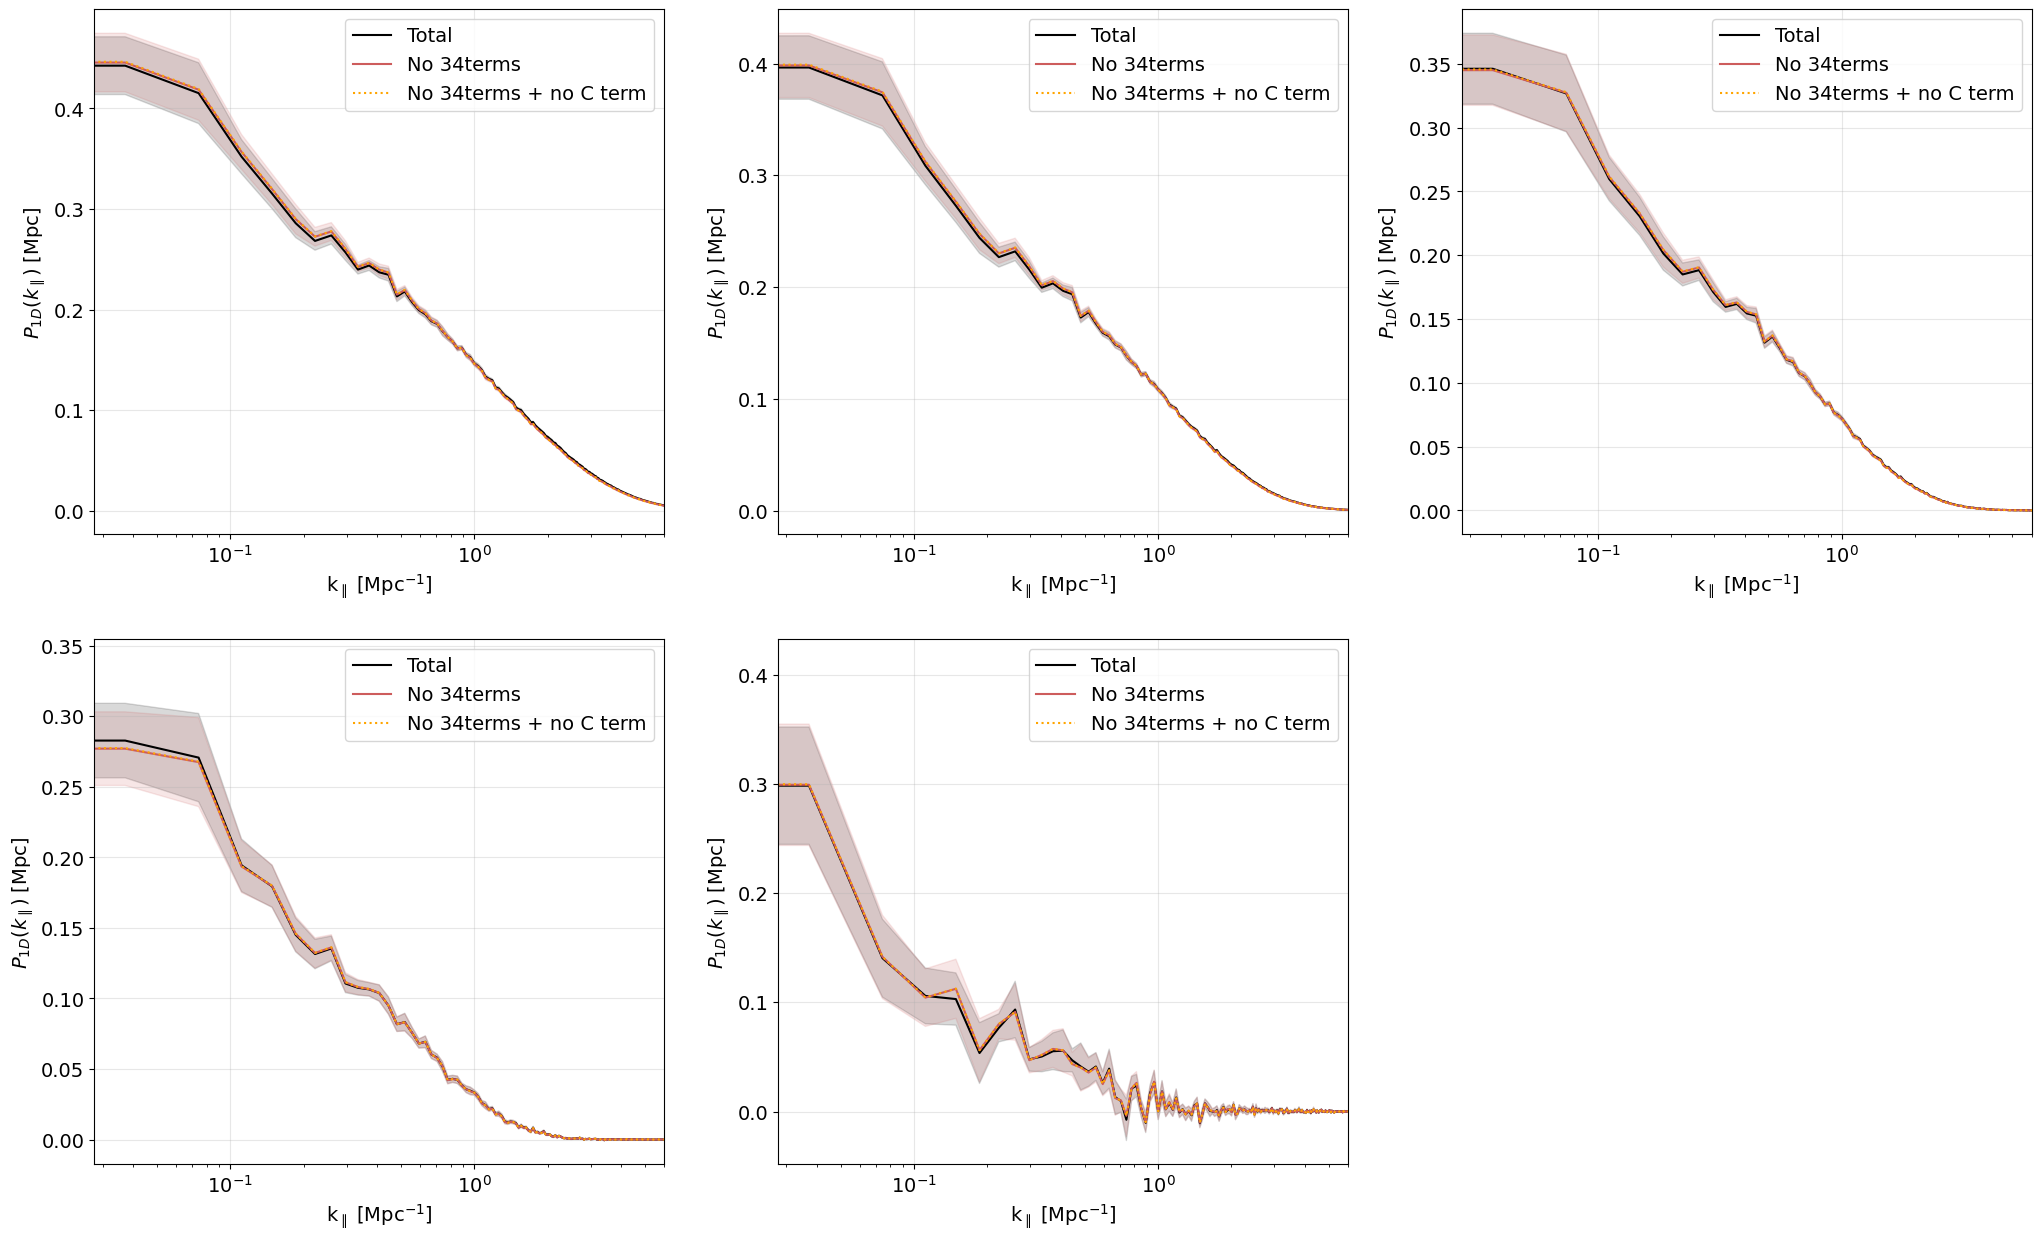

In [18]:
plt.figure(figsize=(25, 15))

for i in np.arange(len(r_bins)-1):
    plt.subplot(2, 3, i+1)
    plt.plot(k_los, Px_tot[i], color='k', label='Total')
    plt.fill_between(k_los, (Px_tot[i]-Px_std_tot[i]), (Px_tot[i]+Px_std_tot[i]), color='k', alpha=0.15)
    plt.plot(k_los, Px_aprox[i], color='indianred', label='No 34terms')
    plt.fill_between(k_los, (Px_aprox[i]-Px_maxstd_aprox[i]), (Px_aprox[i]+Px_maxstd_aprox[i]), color='indianred', alpha=0.15)
    plt.plot(k_los, Px_aprox_vega[i], color='orange', linestyle=':', label='No 34terms + no C term')
    plt.xscale('log')
    plt.legend(fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(alpha=0.3)
    plt.xlim(right=6)
    plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]', fontsize=14)
    plt.ylabel(r'$P_{1D}(k_\parallel)$ [Mpc]', fontsize=14);
    
    plt.savefig('plot.png', dpi=200, bbox_inches='tight')

In [19]:
lost_info = np.mean((Px_aprox-Px_tot)*100, axis=0)

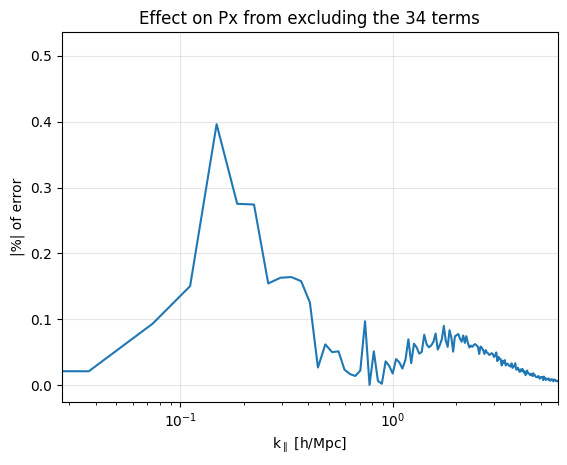

In [22]:
plt.plot(k_los, np.abs(lost_info))
plt.xscale('log')
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.xlabel(r'k$_\parallel$ [h/Mpc]')
plt.ylabel('|%| of error')
plt.title('Effect on Px from excluding the 34 terms');